# PART IV QUALITY — Compare Human and AI Reviews (Style-Controlled / Rephrased)

This notebook mirrors `compare_reviews.ipynb` but uses AI reviews generated on rephrased proposals.

**Review data:** `data/reviews/ai_reviews/ai_reviews_rephrased_*.json`
**Proposal data:** `data/*/rephrased/`

## 0) Environment setup (run once if needed)


In [1]:
# Uncomment if needed
# %pip install -q numpy pandas scipy matplotlib seaborn openpyxl textblob transformers torch scikit-learn statsmodels krippendorff


## 1) Imports, paths, and constants


In [2]:
import json
import re
import itertools
from pathlib import Path
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu, kruskal, wilcoxon, spearmanr, kendalltau, linregress
from sklearn.metrics.pairwise import cosine_similarity
from textblob import TextBlob

import torch
from transformers import AutoTokenizer, AutoModel

sns.set_theme(style='whitegrid', context='talk')

AI_REVIEWS_PATH = sorted(Path('../data/reviews/ai_reviews').glob('ai_reviews_rephrased_*.json'))[-1]
HUMAN_Y1_REVIEWS_PATH = Path('../data/reviews/human_reviews/human_reviews_human-y1.xlsx')
OUTPUT_DIR = Path('../results/figures/quality')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

colors = {
    'Human': '#DC143C',
    'claude-opus-4-5': '#4A90E2',
    'gemini-3-pro-preview': '#7B68EE',
    'gpt-5.2': '#FF8C00',
}

CRITERIA_ORDER = [
    'Relevance_to_Emergent_Phenomena',
    'Novelty_and_Significance',
    'Rigor_of_Approach',
    'Scope_and_Timeline',
    'Synthesis_Focus',
    'Data_Identification',
    'Open_Science_Commitment',
]

CRITERION_MAP = {
    'Relevance to Emergent Phenomena': 'Relevance_to_Emergent_Phenomena',
    'Novelty & Significance': 'Novelty_and_Significance',
    'Rigor of Approach': 'Rigor_of_Approach',
    'Scope & Timeline': 'Scope_and_Timeline',
    'Synthesis Focus': 'Synthesis_Focus',
    'Data Identification': 'Data_Identification',
    'Open Science Commitment': 'Open_Science_Commitment',
}

HUMAN_COL_MAP = {
    'scientific_merit_and_innovation_score': ['Relevance_to_Emergent_Phenomena', 'Novelty_and_Significance', 'Rigor_of_Approach'],
    'feasibility_score': ['Scope_and_Timeline'],
    'data_sources_and_limitations_score': ['Synthesis_Focus', 'Data_Identification'],
    'open_science_compliance_score': ['Open_Science_Commitment'],
}

SHARED_METRICS_4CAT = [
    'Scientific_Merit_and_Innovation',
    'Feasibility',
    'Data_Sources_and_Limitations',
    'Open_Science_Compliance',
]


## 2) Utility functions


In [3]:
def normalize_title(x: str) -> str:
    if pd.isna(x):
        return ''
    x = str(x).lower().strip()
    x = re.sub(r'[^a-z0-9]+', ' ', x)
    x = re.sub(r'\s+', ' ', x).strip()
    return x


def token_set_jaccard(a: str, b: str) -> float:
    sa = set(a.split())
    sb = set(b.split())
    if not sa and not sb:
        return 1.0
    if not sa or not sb:
        return 0.0
    return len(sa & sb) / len(sa | sb)


def hybrid_similarity(a: str, b: str) -> float:
    seq = SequenceMatcher(None, a, b).ratio()
    jac = token_set_jaccard(a, b)
    return 0.7 * seq + 0.3 * jac


def cliffs_delta(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    if len(x) == 0 or len(y) == 0:
        return np.nan
    gt = 0
    lt = 0
    for xi in x:
        gt += np.sum(xi > y)
        lt += np.sum(xi < y)
    return (gt - lt) / (len(x) * len(y))


def interpret_cliffs_delta(delta):
    if np.isnan(delta):
        return 'NA'
    ad = abs(delta)
    if ad < 0.147:
        return 'negligible'
    if ad < 0.33:
        return 'small'
    if ad < 0.474:
        return 'medium'
    return 'large'


def benjamini_hochberg(pvalues):
    p = np.array(pvalues, dtype=float)
    n = len(p)
    if n == 0:
        return p
    order = np.argsort(p)
    ranked = p[order]
    q = np.empty(n)
    prev = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        q[i] = prev
    out = np.empty(n)
    out[order] = np.clip(q, 0, 1)
    return out


def add_bh_fdr(df, p_col='p_value', group_cols=None, out_col='q_value'):
    df = df.copy()
    if group_cols is None:
        df[out_col] = benjamini_hochberg(df[p_col].values)
        return df
    df[out_col] = np.nan
    for _, idx in df.groupby(group_cols).groups.items():
        idx = list(idx)
        df.loc[idx, out_col] = benjamini_hochberg(df.loc[idx, p_col].values)
    return df


def mannwhitney_summary(a, b, metric_name='metric'):
    a = pd.Series(a).dropna().to_numpy()
    b = pd.Series(b).dropna().to_numpy()
    if len(a) == 0 or len(b) == 0:
        return {
            'metric': metric_name,
            'n_group1': len(a),
            'n_group2': len(b),
            'u_stat': np.nan,
            'p_value': np.nan,
            'cliffs_delta': np.nan,
            'delta_magnitude': 'NA',
        }
    u, p = mannwhitneyu(a, b, alternative='two-sided')
    d = cliffs_delta(a, b)
    return {
        'metric': metric_name,
        'n_group1': len(a),
        'n_group2': len(b),
        'u_stat': u,
        'p_value': p,
        'cliffs_delta': d,
        'delta_magnitude': interpret_cliffs_delta(d),
    }


def sentiment_label(p):
    if p > 0.1:
        return 'positive'
    if p < -0.1:
        return 'negative'
    return 'neutral'


def sentiment_alignment(p1, p2):
    return 1 - (abs(p1 - p2) / 2)


def categorical_agreement(l1, l2):
    if l1 == l2:
        return 'agree'
    if {'positive', 'negative'} == {l1, l2}:
        return 'disagree'
    return 'partial'


def bootstrap_mean_diff_ci(x, y, n_boot=2000, ci=0.95, seed=42):
    rng = np.random.default_rng(seed)
    x = np.asarray(pd.Series(x).dropna().values, dtype=float)
    y = np.asarray(pd.Series(y).dropna().values, dtype=float)
    if len(x) == 0 or len(y) == 0:
        return np.nan, np.nan, np.nan
    diffs = []
    for _ in range(n_boot):
        xb = rng.choice(x, size=len(x), replace=True)
        yb = rng.choice(y, size=len(y), replace=True)
        diffs.append(np.mean(xb) - np.mean(yb))
    diffs = np.array(diffs)
    alpha = (1 - ci) / 2
    lo = np.quantile(diffs, alpha)
    hi = np.quantile(diffs, 1 - alpha)
    return np.mean(x) - np.mean(y), lo, hi


def permutation_p_value_mean_diff(x, y, n_perm=5000, seed=42):
    rng = np.random.default_rng(seed)
    x = np.asarray(pd.Series(x).dropna().values, dtype=float)
    y = np.asarray(pd.Series(y).dropna().values, dtype=float)
    if len(x) == 0 or len(y) == 0:
        return np.nan
    obs = abs(np.mean(x) - np.mean(y))
    pooled = np.concatenate([x, y]).copy()
    n_x = len(x)
    count = 0
    for _ in range(n_perm):
        rng.shuffle(pooled)
        xp = pooled[:n_x]
        yp = pooled[n_x:]
        if abs(np.mean(xp) - np.mean(yp)) >= obs:
            count += 1
    return (count + 1) / (n_perm + 1)


def icc2_1_2k(ratings_matrix):
    # ICC(2,1) and ICC(2,k) for complete items x raters matrix
    X = np.asarray(ratings_matrix, dtype=float)
    if np.isnan(X).any():
        return np.nan, np.nan
    n, k = X.shape
    if n < 2 or k < 2:
        return np.nan, np.nan

    mean_row = X.mean(axis=1, keepdims=True)
    mean_col = X.mean(axis=0, keepdims=True)
    grand = X.mean()

    ss_row = k * np.sum((mean_row - grand) ** 2)
    ss_col = n * np.sum((mean_col - grand) ** 2)
    ss_err = np.sum((X - mean_row - mean_col + grand) ** 2)

    ms_row = ss_row / (n - 1)
    ms_col = ss_col / (k - 1)
    ms_err = ss_err / ((n - 1) * (k - 1))

    icc21 = (ms_row - ms_err) / (ms_row + (k - 1) * ms_err + (k * (ms_col - ms_err) / n))
    icc2k = (ms_row - ms_err) / (ms_row + ((ms_col - ms_err) / n))
    return icc21, icc2k


def build_one_to_one_title_mapping(human_proposals, ai_proposals, fuzzy_threshold=0.70):
    h = human_proposals.copy().reset_index(drop=True)
    a = ai_proposals.copy().reset_index(drop=True)

    assigned_h = set()
    assigned_a = set()
    rows = []

    ai_by_norm = a.groupby('ai_title_norm')['ai_proposal_id'].apply(list).to_dict()
    for _, hr in h.iterrows():
        hp = hr['human_proposal_id']
        hn = hr['human_title_norm']
        candidates = ai_by_norm.get(hn, [])
        candidates = [x for x in candidates if x not in assigned_a]
        if len(candidates) == 1:
            ap = candidates[0]
            ar = a.loc[a['ai_proposal_id'] == ap].iloc[0]
            rows.append({
                'human_proposal_id': hp,
                'ai_proposal_id': ap,
                'human_title': hr['human_title'],
                'ai_title': ar['ai_title'],
                'human_title_norm': hn,
                'ai_title_norm': ar['ai_title_norm'],
                'similarity': 1.0,
                'match_method': 'exact',
            })
            assigned_h.add(hp)
            assigned_a.add(ap)

    h_un = h[~h['human_proposal_id'].isin(assigned_h)]
    a_un = a[~a['ai_proposal_id'].isin(assigned_a)]

    candidates = []
    for _, hr in h_un.iterrows():
        for _, ar in a_un.iterrows():
            sim = hybrid_similarity(hr['human_title_norm'], ar['ai_title_norm'])
            candidates.append((sim, hr['human_proposal_id'], ar['ai_proposal_id']))

    candidates = sorted(candidates, key=lambda x: x[0], reverse=True)
    used_h = set()
    used_a = set()

    for sim, hp, ap in candidates:
        if sim < fuzzy_threshold:
            break
        if hp in used_h or ap in used_a:
            continue
        hr = h.loc[h['human_proposal_id'] == hp].iloc[0]
        ar = a.loc[a['ai_proposal_id'] == ap].iloc[0]
        rows.append({
            'human_proposal_id': hp,
            'ai_proposal_id': ap,
            'human_title': hr['human_title'],
            'ai_title': ar['ai_title'],
            'human_title_norm': hr['human_title_norm'],
            'ai_title_norm': ar['ai_title_norm'],
            'similarity': sim,
            'match_method': 'fuzzy',
        })
        used_h.add(hp)
        used_a.add(ap)

    mapping = pd.DataFrame(rows)

    h_unmatched = sorted(set(h['human_proposal_id']) - set(mapping['human_proposal_id']))
    a_unmatched = sorted(set(a['ai_proposal_id']) - set(mapping['ai_proposal_id']))

    diagnostics = {
        'n_human_proposals': int(h.shape[0]),
        'n_ai_proposals': int(a.shape[0]),
        'n_matched': int(mapping.shape[0]),
        'n_exact': int((mapping['match_method'] == 'exact').sum()) if not mapping.empty else 0,
        'n_fuzzy': int((mapping['match_method'] == 'fuzzy').sum()) if not mapping.empty else 0,
        'n_unmatched_human': int(len(h_unmatched)),
        'n_unmatched_ai': int(len(a_unmatched)),
    }

    return mapping, diagnostics, h_unmatched, a_unmatched


## 3) Load and flatten AI reviews


In [4]:
with open(AI_REVIEWS_PATH, 'r') as f:
    ai_payload = json.load(f)

rows = []
for r in ai_payload.get('reviews', []):
    ev = (r.get('evaluations') or {}).get('evaluation')
    if not isinstance(ev, dict):
        continue

    criteria = {k: np.nan for k in CRITERIA_ORDER}
    justifications = []

    for category in ev.get('criteria_scores', []) or []:
        for sc in category.get('subcriteria', []) or []:
            c_name = CRITERION_MAP.get(sc.get('criterion'))
            if c_name is not None:
                criteria[c_name] = sc.get('score', np.nan)
            j = sc.get('justification')
            if isinstance(j, str) and j.strip():
                justifications.append(j.strip())

    overall = ev.get('overall_rating') or {}
    overall_score = overall.get('final_numeric_score', np.nan)
    overall_summary = overall.get('narrative_summary', '')

    review_text = "\n\n".join(justifications + ([overall_summary] if overall_summary else []))

    row = {
        'proposal_id': r.get('proposal_id'),
        'title': r.get('title'),
        'title_norm': normalize_title(r.get('title', '')),
        'author': r.get('author'),
        'evaluator': r.get('evaluator'),
        'overall_score': overall_score,
        'review_text': review_text,
    }
    row.update(criteria)
    rows.append(row)

ai_df = pd.DataFrame(rows)
ai_df['proposal_uid'] = ai_df['author'].astype(str) + '::' + ai_df['proposal_id'].astype(str)

for c in ['overall_score'] + CRITERIA_ORDER:
    ai_df[c] = pd.to_numeric(ai_df[c], errors='coerce')

# Use title_norm as fallback proposal_id when proposal_id is None
mask = ai_df['proposal_id'].isna()
if mask.any():
    ai_df.loc[mask, 'proposal_id'] = ai_df.loc[mask, 'title_norm']

print('AI reviews rows:', len(ai_df))
print('Authors:', sorted(ai_df['author'].dropna().unique()))
print('Evaluators:', sorted(ai_df['evaluator'].dropna().unique()))
ai_df.head(3)


AI reviews rows: 276
Authors: ['claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2', 'human-y1', 'human-y2']
Evaluators: ['claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']


,proposal_id,title,title_norm,author,evaluator,overall_score,review_text,Relevance_to_Emergent_Phenomena,Novelty_and_Significance,Rigor_of_Approach,Scope_and_Timeline,Synthesis_Focus,Data_Identification,Open_Science_Commitment,proposal_uid
0,a cross cell type atlas of biomolecular conden...,A Cross-Cell-Type Atlas of Biomolecular Conden...,a cross cell type atlas of biomolecular conden...,gpt-5.2,gpt-5.2,3.8,The proposal directly targets condensate mater...,5,4,3,3,5,3,4,gpt-5.2::None
1,a cross cell type atlas of biomolecular conden...,A Cross-Cell-Type Atlas of Biomolecular Conden...,a cross cell type atlas of biomolecular conden...,gpt-5.2,gemini-3-pro-preview,4.4,The proposal directly and explicitly addresses...,5,5,4,4,5,3,5,gpt-5.2::None
2,a cross cell type atlas of biomolecular conden...,A Cross-Cell-Type Atlas of Biomolecular Conden...,a cross cell type atlas of biomolecular conden...,gpt-5.2,claude-opus-4-5,3.5,The proposal directly and explicitly addresses...,5,4,3,2,5,3,4,gpt-5.2::None


## 4) Load and flatten human Y1 expert reviews


In [5]:
human_raw = pd.read_excel(HUMAN_Y1_REVIEWS_PATH)

human_df = human_raw.copy()
human_df['author'] = 'human-y1'
human_df['evaluator'] = human_df['reviewer_id'].astype(str).map(lambda x: f'human-reviewer-{x}')
human_df['title_norm'] = human_df['title'].map(normalize_title)

for col in HUMAN_COL_MAP.keys():
    human_df[col] = pd.to_numeric(human_df[col], errors='coerce')

human_df['overall_score'] = pd.to_numeric(human_df['overall_rating_score'], errors='coerce')
human_df['overall_score'] = human_df['overall_score'].fillna(
    human_df[list(HUMAN_COL_MAP.keys())].mean(axis=1, skipna=True)
)

for c in CRITERIA_ORDER:
    human_df[c] = np.nan

for src_col, targets in HUMAN_COL_MAP.items():
    for t in targets:
        human_df[t] = human_df[src_col]

human_text_cols = [
    'scientific_merit_and_innovation_justification',
    'feasibility_justification',
    'data_sources_and_limitations_justification',
    'open_science_compliance_justification',
    'overall_rating_summary',
]

def merge_text(row):
    parts = [str(row[c]).strip() for c in human_text_cols if isinstance(row[c], str) and row[c].strip()]
    return "\n\n".join(parts)

human_df['review_text'] = human_df.apply(merge_text, axis=1)

human_df = human_df[[
    'id', 'title', 'title_norm', 'author', 'evaluator', 'overall_score', 'review_text', *CRITERIA_ORDER
]].rename(columns={'id': 'proposal_id'})

human_df['proposal_id'] = human_df['proposal_id'].astype(str)
human_df['proposal_uid'] = 'human-y1::' + human_df['proposal_id']

print('Human Y1 rows:', len(human_df))
print('Unique proposals:', human_df['proposal_id'].nunique())
human_df.head(3)


Human Y1 rows: 47
Unique proposals: 12


,proposal_id,title,title_norm,author,evaluator,overall_score,review_text,Relevance_to_Emergent_Phenomena,Novelty_and_Significance,Rigor_of_Approach,Scope_and_Timeline,Synthesis_Focus,Data_Identification,Open_Science_Commitment,proposal_uid
0,1,CYTOKINETIC BOTTLENECKS OF HEAT WAVES,cytokinetic bottlenecks of heat waves,human-y1,human-reviewer-1,NaN,Team leaders identify cytokinesis as a major c...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,human-y1::1
1,1,CYTOKINETIC BOTTLENECKS OF HEAT WAVES,cytokinetic bottlenecks of heat waves,human-y1,human-reviewer-2,5.0,Relevance to Emergent Phenomena: \nThe proposa...,5.0,5.0,5.0,4.0,5.0,5.0,5.0,human-y1::1
2,1,CYTOKINETIC BOTTLENECKS OF HEAT WAVES,cytokinetic bottlenecks of heat waves,human-y1,human-reviewer-3,5.0,This proposal will adress an important and eme...,4.0,4.0,4.0,4.0,5.0,5.0,3.0,human-y1::1


## 5) Proposal matching diagnostics (exact + fuzzy fallback)

This fixes the prior issue where title-exact matching dropped proposals.


In [6]:
ai_y1 = ai_df[ai_df['author'] == 'human-y1'].copy()

human_props = (
    human_df[['proposal_id', 'title', 'title_norm']]
    .drop_duplicates(subset=['proposal_id'])
    .rename(columns={
        'proposal_id': 'human_proposal_id',
        'title': 'human_title',
        'title_norm': 'human_title_norm',
    })
)

ai_props = (
    ai_y1[['proposal_id', 'title', 'title_norm']]
    .drop_duplicates(subset=['title_norm'])
    .rename(columns={
        'proposal_id': 'ai_proposal_id',
        'title': 'ai_title',
        'title_norm': 'ai_title_norm',
    })
)

mapping_df, mapping_diag, h_unmatched, a_unmatched = build_one_to_one_title_mapping(
    human_props,
    ai_props,
    fuzzy_threshold=0.70,
)

mapping_df = mapping_df.sort_values('human_proposal_id').reset_index(drop=True)
mapping_df['proposal_key'] = [f'Y1_{i+1:02d}' for i in range(len(mapping_df))]

print('Mapping diagnostics:', mapping_diag)
print('Unmatched human proposal_ids:', h_unmatched)
print('Unmatched ai proposal_ids:', a_unmatched)

mapping_df[['proposal_key', 'human_proposal_id', 'ai_proposal_id', 'match_method', 'similarity', 'human_title', 'ai_title']]

Mapping diagnostics: {'n_human_proposals': 12, 'n_ai_proposals': 12, 'n_matched': 8, 'n_exact': 1, 'n_fuzzy': 7, 'n_unmatched_human': 4, 'n_unmatched_ai': 4}
Unmatched human proposal_ids: ['1', '11', '4', '9']
Unmatched ai proposal_ids: ['exploration of the crosslinking mass spectrometry landscape for novel protein protein interaction discovery', 'impact of heat wave stress on cytokinetic bottlenecks in cellular division', 'integrated transfer learning for mesoscale organization principles via image data and biophysical simulations', 'synthesis of gene expression data for the construction of a bacterial cell state atlas']


,proposal_key,human_proposal_id,ai_proposal_id,match_method,similarity,human_title,ai_title
0,Y1_01,10,the role of transposable elements in the emerg...,fuzzy,0.831053,Transposable elements and the emergence of gen...,The Role of Transposable Elements in the Emerg...
1,Y1_02,12,intelligent metadata compilation for enhanced ...,fuzzy,0.802134,Intelligent metadata compilation to enhance th...,Intelligent Metadata Compilation for Enhanced ...
2,Y1_03,2,elucidation of genome structure function relat...,fuzzy,0.894372,Elucidating genome structure-function relation...,Elucidation of Genome Structure-Function Relat...
3,Y1_04,3,maitool large language model powered bioinform...,fuzzy,0.808840,MaiTool - LLM-powered bioinformatics tools for...,MaiTool: Large Language Model-Powered Bioinfor...
4,Y1_05,5,energetic origins of connectivity within prote...,exact,1.000000,Energetic Origins of Connectivity within Prote...,Energetic Origins of Connectivity within Prote...
5,Y1_06,6,elucidation of emergent structural patterns in...,fuzzy,0.801782,Elucidating emergent structures in cellular RN...,Elucidation of Emergent Structural Patterns in...
6,Y1_07,7,the role of intrinsically disordered proteins ...,fuzzy,0.704000,Elucidating the Role of Disordered Proteins in...,The Role of Intrinsically Disordered Proteins ...
7,Y1_08,8,multimodal single cell analytical frameworks f...,fuzzy,0.929971,Multimodal Single-Cell Frameworks for Cell Lin...,Multimodal Single-Cell Analytical Frameworks f...


## 6) Build matched review sets, embeddings, and pair table (single source of truth)


In [7]:
MODEL_NAME = 'michiyasunaga/BioLinkBERT-large'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device)
model.eval()


def embed_texts(texts, batch_size=8, max_len=512):
    all_emb = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i + batch_size]
            tok = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=max_len,
                return_tensors='pt'
            )
            tok = {k: v.to(device) for k, v in tok.items()}
            out = model(**tok)

            attn = tok['attention_mask'].unsqueeze(-1)
            masked = out.last_hidden_state * attn
            denom = attn.sum(dim=1).clamp(min=1)
            emb = masked.sum(dim=1) / denom
            emb = torch.nn.functional.normalize(emb, p=2, dim=1)
            all_emb.append(emb.cpu().numpy())
    return np.vstack(all_emb)


h = human_df.merge(
    mapping_df[['human_proposal_id', 'proposal_key', 'match_method']],
    left_on='proposal_id',
    right_on='human_proposal_id',
    how='inner',
).copy()

a = ai_y1.merge(
    mapping_df[['ai_proposal_id', 'proposal_key', 'match_method']],
    left_on='proposal_id',
    right_on='ai_proposal_id',
    how='inner',
).copy()

h = h.reset_index(drop=True)
a = a.reset_index(drop=True)
h['review_uid'] = [f'H_{i:04d}' for i in range(len(h))]
a['review_uid'] = [f'A_{i:04d}' for i in range(len(a))]

h_emb = embed_texts(h['review_text'].fillna('').tolist())
a_emb = embed_texts(a['review_text'].fillna('').tolist())

h['embedding'] = list(h_emb)
a['embedding'] = list(a_emb)

for df in [h, a]:
    pol = [TextBlob(t).sentiment.polarity for t in df['review_text'].fillna('')]
    df['polarity'] = pol
    df['sent_label'] = [sentiment_label(p) for p in pol]

records = []
for pk in sorted(set(h['proposal_key']).intersection(set(a['proposal_key']))):
    hg = h[h['proposal_key'] == pk]
    ag = a[a['proposal_key'] == pk]

    for _, hr in hg.iterrows():
        for _, ar in ag.iterrows():
            cos = float(cosine_similarity([hr['embedding']], [ar['embedding']])[0, 0])
            align = sentiment_alignment(hr['polarity'], ar['polarity'])
            cag = categorical_agreement(hr['sent_label'], ar['sent_label'])
            records.append({
                'pair_type': 'human-ai',
                'proposal_key': pk,
                'match_method': hr['match_method'],
                'human_reviewer': hr['evaluator'],
                'ai_model': ar['evaluator'],
                'cosine_similarity': cos,
                'sentiment_alignment': align,
                'categorical_agreement': cag,
                'categorical_agreement_num': {'disagree': 0, 'partial': 1, 'agree': 2}[cag],
            })

    for (_, a1), (_, a2) in itertools.combinations(ag.iterrows(), 2):
        cos = float(cosine_similarity([a1['embedding']], [a2['embedding']])[0, 0])
        align = sentiment_alignment(a1['polarity'], a2['polarity'])
        cag = categorical_agreement(a1['sent_label'], a2['sent_label'])
        m1 = a1['evaluator']
        m2 = a2['evaluator']
        records.append({
            'pair_type': 'ai-ai',
            'proposal_key': pk,
            'match_method': a1['match_method'],
            'ai_model_1': m1,
            'ai_model_2': m2,
            'ai_model_pair': ' vs '.join(sorted([str(m1), str(m2)])),
            'cosine_similarity': cos,
            'sentiment_alignment': align,
            'categorical_agreement': cag,
            'categorical_agreement_num': {'disagree': 0, 'partial': 1, 'agree': 2}[cag],
        })

    for (_, h1), (_, h2) in itertools.combinations(hg.iterrows(), 2):
        cos = float(cosine_similarity([h1['embedding']], [h2['embedding']])[0, 0])
        align = sentiment_alignment(h1['polarity'], h2['polarity'])
        cag = categorical_agreement(h1['sent_label'], h2['sent_label'])
        records.append({
            'pair_type': 'human-human',
            'proposal_key': pk,
            'match_method': h1['match_method'],
            'human_reviewer_1': h1['evaluator'],
            'human_reviewer_2': h2['evaluator'],
            'cosine_similarity': cos,
            'sentiment_alignment': align,
            'categorical_agreement': cag,
            'categorical_agreement_num': {'disagree': 0, 'partial': 1, 'agree': 2}[cag],
        })

pair_df = pd.DataFrame(records)

print('Matched proposals:', pair_df['proposal_key'].nunique())
print('Pair counts by type:')
print(pair_df['pair_type'].value_counts())
print('Human-AI pairs by AI model:')
print(pair_df[pair_df['pair_type'] == 'human-ai']['ai_model'].value_counts())
print('AI-AI pairs by model pair:')
print(pair_df[pair_df['pair_type'] == 'ai-ai']['ai_model_pair'].value_counts())

pair_df.head()


Matched proposals: 8
Pair counts by type:
pair_type
human-ai       96
human-human    49
ai-ai          24
Name: count, dtype: int64
Human-AI pairs by AI model:
ai_model
gpt-5.2                 32
gemini-3-pro-preview    32
claude-opus-4-5         32
Name: count, dtype: int64
AI-AI pairs by model pair:
ai_model_pair
gemini-3-pro-preview vs gpt-5.2            8
claude-opus-4-5 vs gpt-5.2                 8
claude-opus-4-5 vs gemini-3-pro-preview    8
Name: count, dtype: int64


,pair_type,proposal_key,match_method,human_reviewer,ai_model,cosine_similarity,sentiment_alignment,categorical_agreement,categorical_agreement_num,ai_model_1,ai_model_2,ai_model_pair,human_reviewer_1,human_reviewer_2
0,human-ai,Y1_01,fuzzy,human-reviewer-1,gpt-5.2,0.946651,0.989897,partial,1,NaN,NaN,NaN,NaN,NaN
1,human-ai,Y1_01,fuzzy,human-reviewer-1,gemini-3-pro-preview,0.955556,0.954995,agree,2,NaN,NaN,NaN,NaN,NaN
2,human-ai,Y1_01,fuzzy,human-reviewer-1,claude-opus-4-5,0.954378,0.983466,agree,2,NaN,NaN,NaN,NaN,NaN
3,human-ai,Y1_01,fuzzy,human-reviewer-2,gpt-5.2,0.920628,0.972934,partial,1,NaN,NaN,NaN,NaN,NaN
4,human-ai,Y1_01,fuzzy,human-reviewer-2,gemini-3-pro-preview,0.962688,0.971959,agree,2,NaN,NaN,NaN,NaN,NaN


## 7) Pair count checks (expected vs observed)


In [8]:
def _nC2(n: int) -> int:
    n = int(n)
    return (n * (n - 1)) // 2 if n >= 2 else 0

unique_pks = sorted(set(h['proposal_key']).intersection(set(a['proposal_key'])))
human_counts = h.groupby('proposal_key').size().reindex(unique_pks, fill_value=0).rename('n_human_reviews')
ai_counts_total = a.groupby('proposal_key').size().reindex(unique_pks, fill_value=0).rename('n_ai_reviews_total')
ai_counts_by_model = (
    a.pivot_table(index='proposal_key', columns='evaluator', values='review_uid', aggfunc='size', fill_value=0)
    .reindex(unique_pks, fill_value=0)
)

counts_df = pd.concat([human_counts, ai_counts_total, ai_counts_by_model], axis=1).fillna(0).astype(int)
display(counts_df)

expected_human_ai_total = int((counts_df['n_human_reviews'] * counts_df['n_ai_reviews_total']).sum())
expected_human_human_total = int(counts_df['n_human_reviews'].map(_nC2).sum())
expected_ai_ai_total = int(counts_df['n_ai_reviews_total'].map(_nC2).sum())

observed_totals = pair_df['pair_type'].value_counts().to_dict()

print('Expected totals:', {
    'human-ai': expected_human_ai_total,
    'human-human': expected_human_human_total,
    'ai-ai': expected_ai_ai_total,
})
print('Observed totals:', observed_totals)


,n_human_reviews,n_ai_reviews_total,claude-opus-4-5,gemini-3-pro-preview,gpt-5.2
proposal_key,,,,,
Y1_01,4,3,1,1,1
Y1_02,4,3,1,1,1
Y1_03,3,3,1,1,1
Y1_04,4,3,1,1,1
Y1_05,4,3,1,1,1
Y1_06,4,3,1,1,1
Y1_07,4,3,1,1,1
Y1_08,5,3,1,1,1


Expected totals: {'human-ai': 96, 'human-human': 49, 'ai-ai': 24}
Observed totals: {'human-ai': 96, 'human-human': 49, 'ai-ai': 24}


## 8) Similarity proxy stats (proposal-level, model-aware, FDR-corrected)

**Purpose**
This section evaluates whether AI review text behaves like a reliable proxy for human expert review text quality judgments.

**How this is done**
1. Aggregate pairwise metrics to proposal-level means (human-human, human-AI, AI-AI) to reduce pseudo-replication.
2. **Primary test: paired Wilcoxon signed-rank** on the matched proposal-level means across comparison types.
3. **Secondary / sensitivity check: Mann-Whitney U + Cliff's delta** (reported but not primary — see note on independence below).
4. Apply Benjamini-Hochberg FDR correction within each metric family.
5. Break down results by AI model (`human-ai`) and AI model pair (`ai-ai`).

**Statistical note: why Wilcoxon is the primary test**

Mann-Whitney U assumes the two samples are **independent**. That assumption is violated here:
the same ~12 proposals appear in both `human-ai` and `human-human` (and `ai-ai`), so their
proposal-level means are paired — a proposal that is clearer or more coherent will tend to score
similarly in all comparison types. Using Mann-Whitney as the primary test risks inflated Type I
errors because it ignores this positive within-proposal correlation.

The **paired Wilcoxon signed-rank test** handles this correctly by testing the signed differences
on matched proposal pairs, and is the appropriate primary statistic. Mann-Whitney is retained as a
sensitivity check for robustness (e.g. to detect whether the pairing assumption itself drives results).

For the model-stratified comparisons (`human-ai::model` vs `human-human`), the same proposals
appear in both groups, so Wilcoxon remains the primary test there too.


In [9]:
# Purpose:
# Summarize similarity metrics at proposal-level and test whether human-AI / AI-AI
# comparisons differ from human-human baseline.
#
# PRIMARY test: paired Wilcoxon signed-rank (same ~12 proposals appear in both groups
#   being compared, so the two samples are NOT independent -> Mann-Whitney U assumption
#   violated; Wilcoxon exploits the matched structure correctly).
#
# SECONDARY: Mann-Whitney U + Cliff's delta retained as a sensitivity / robustness check.
#
# FDR correction applied within each metric family (BH).
SIM_METRICS = ['cosine_similarity', 'sentiment_alignment', 'categorical_agreement_num']

human_human_prop = (
    pair_df[pair_df['pair_type'] == 'human-human']
    .groupby('proposal_key')[SIM_METRICS]
    .mean()
    .reset_index()
)
human_ai_prop = (
    pair_df[pair_df['pair_type'] == 'human-ai']
    .groupby('proposal_key')[SIM_METRICS]
    .mean()
    .reset_index()
)
ai_ai_prop = (
    pair_df[pair_df['pair_type'] == 'ai-ai']
    .groupby('proposal_key')[SIM_METRICS]
    .mean()
    .reset_index()
)

overall_tests = []
for m in SIM_METRICS:
    for g1_name, g1_df, g2_name, g2_df in [
        ('human-ai', human_ai_prop, 'human-human', human_human_prop),
        ('ai-ai', ai_ai_prop, 'human-human', human_human_prop),
        ('ai-ai', ai_ai_prop, 'human-ai', human_ai_prop),
    ]:
        out = mannwhitney_summary(g1_df[m], g2_df[m], metric_name=m)
        out['group1'] = g1_name
        out['group2'] = g2_name

        merged = g1_df[['proposal_key', m]].merge(g2_df[['proposal_key', m]], on='proposal_key', suffixes=('_1', '_2'))
        try:
            w_stat, w_p = wilcoxon(merged[f'{m}_1'], merged[f'{m}_2'])
        except Exception:
            w_stat, w_p = np.nan, np.nan
        out['wilcoxon_stat'] = w_stat
        out['wilcoxon_p_value'] = w_p
        out['n_paired_proposals'] = len(merged)

        overall_tests.append(out)

sim_stats_overall_df = pd.DataFrame(overall_tests)
sim_stats_overall_df = add_bh_fdr(sim_stats_overall_df, p_col='p_value', group_cols=['metric'])

human_ai_by_model_prop = (
    pair_df[pair_df['pair_type'] == 'human-ai']
    .groupby(['proposal_key', 'ai_model'])[SIM_METRICS]
    .mean()
    .reset_index()
)

rows = []
for m in SIM_METRICS:
    for model in sorted(human_ai_by_model_prop['ai_model'].dropna().unique()):
        sub = human_ai_by_model_prop[human_ai_by_model_prop['ai_model'] == model]
        out = mannwhitney_summary(sub[m], human_human_prop[m], metric_name=m)
        out['group1'] = f'human-ai::{model}'
        out['group2'] = 'human-human'
        out['ai_model'] = model
        rows.append(out)

sim_stats_hai_by_model_df = pd.DataFrame(rows)
sim_stats_hai_by_model_df = add_bh_fdr(sim_stats_hai_by_model_df, p_col='p_value', group_cols=['metric'])

ai_ai_by_pair_prop = (
    pair_df[pair_df['pair_type'] == 'ai-ai']
    .groupby(['proposal_key', 'ai_model_pair'])[SIM_METRICS]
    .mean()
    .reset_index()
)

rows = []
for m in SIM_METRICS:
    for mp in sorted(ai_ai_by_pair_prop['ai_model_pair'].dropna().unique()):
        sub = ai_ai_by_pair_prop[ai_ai_by_pair_prop['ai_model_pair'] == mp]
        out = mannwhitney_summary(sub[m], human_human_prop[m], metric_name=m)
        out['group1'] = f'ai-ai::{mp}'
        out['group2'] = 'human-human'
        out['ai_model_pair'] = mp
        rows.append(out)

sim_stats_aiai_by_pair_df = pd.DataFrame(rows)
sim_stats_aiai_by_pair_df = add_bh_fdr(sim_stats_aiai_by_pair_df, p_col='p_value', group_cols=['metric'])

# ---- results (Wilcoxon = primary, Mann-Whitney = secondary/sensitivity) ----
cols_primary = ['metric', 'group1', 'group2', 'n_paired_proposals',
                'wilcoxon_stat', 'wilcoxon_p_value',
                'n_group1', 'n_group2', 'u_stat', 'p_value', 'p_value_fdr',
                'cliffs_delta', 'delta_magnitude']

def _reorder(df, cols):
    present = [c for c in cols if c in df.columns]
    rest = [c for c in df.columns if c not in present]
    return df[present + rest]

print('Overall pair-type stats (primary: wilcoxon_p_value, secondary: p_value):')  
display(_reorder(sim_stats_overall_df, cols_primary))
print('Human-AI by model stats:')  
display(_reorder(sim_stats_hai_by_model_df, cols_primary))
print('AI-AI by model-pair stats:')  
display(_reorder(sim_stats_aiai_by_pair_df, cols_primary))


Overall pair-type stats (primary: wilcoxon_p_value, secondary: p_value):


,metric,group1,group2,n_paired_proposals,wilcoxon_stat,wilcoxon_p_value,n_group1,n_group2,u_stat,p_value,cliffs_delta,delta_magnitude,q_value
0,cosine_similarity,human-ai,human-human,8,10.0,0.312500,8,8,26.0,0.573737,-0.18750,small,0.573737
1,cosine_similarity,ai-ai,human-human,8,10.0,0.312500,8,8,40.0,0.441803,0.25000,small,0.573737
2,cosine_similarity,ai-ai,human-ai,8,0.0,0.007812,8,8,64.0,0.000155,1.00000,large,0.000466
3,sentiment_alignment,human-ai,human-human,8,17.0,0.945312,8,8,34.0,0.878477,0.06250,negligible,0.878477
4,sentiment_alignment,ai-ai,human-human,8,11.0,0.382812,8,8,44.0,0.234499,0.37500,medium,0.351748
5,sentiment_alignment,ai-ai,human-ai,8,10.0,0.312500,8,8,47.0,0.130381,0.46875,medium,0.351748
6,categorical_agreement_num,human-ai,human-human,8,9.0,0.250000,8,8,23.0,0.365607,-0.28125,small,0.708228
7,categorical_agreement_num,ai-ai,human-human,8,10.5,0.562500,8,8,26.0,0.529909,-0.18750,small,0.708228
8,categorical_agreement_num,ai-ai,human-ai,8,16.0,0.851562,8,8,36.0,0.708228,0.12500,negligible,0.708228


Human-AI by model stats:


,metric,group1,group2,n_group1,n_group2,u_stat,p_value,cliffs_delta,delta_magnitude,ai_model,q_value
0,cosine_similarity,human-ai::claude-opus-4-5,human-human,8,8,32.0,1.000000,0.00000,negligible,claude-opus-4-5,1.000000
1,cosine_similarity,human-ai::gemini-3-pro-preview,human-human,8,8,25.0,0.505361,-0.21875,small,gemini-3-pro-preview,0.758042
2,cosine_similarity,human-ai::gpt-5.2,human-human,8,8,6.0,0.004662,-0.81250,large,gpt-5.2,0.013986
3,sentiment_alignment,human-ai::claude-opus-4-5,human-human,8,8,37.0,0.645377,0.15625,small,claude-opus-4-5,0.720901
4,sentiment_alignment,human-ai::gemini-3-pro-preview,human-human,8,8,37.0,0.645377,0.15625,small,gemini-3-pro-preview,0.720901
5,sentiment_alignment,human-ai::gpt-5.2,human-human,8,8,28.0,0.720901,-0.12500,negligible,gpt-5.2,0.720901
6,categorical_agreement_num,human-ai::claude-opus-4-5,human-human,8,8,22.0,0.303759,-0.31250,small,claude-opus-4-5,0.455639
7,categorical_agreement_num,human-ai::gemini-3-pro-preview,human-human,8,8,28.0,0.700275,-0.12500,negligible,gemini-3-pro-preview,0.700275
8,categorical_agreement_num,human-ai::gpt-5.2,human-human,8,8,20.0,0.217073,-0.37500,medium,gpt-5.2,0.455639


AI-AI by model-pair stats:


,metric,group1,group2,n_group1,n_group2,u_stat,p_value,cliffs_delta,delta_magnitude,ai_model_pair,q_value
0,cosine_similarity,ai-ai::claude-opus-4-5 vs gemini-3-pro-preview,human-human,8,8,64.0,0.000155,1.00000,large,claude-opus-4-5 vs gemini-3-pro-preview,0.000466
1,cosine_similarity,ai-ai::claude-opus-4-5 vs gpt-5.2,human-human,8,8,33.0,0.959130,0.03125,negligible,claude-opus-4-5 vs gpt-5.2,0.959130
2,cosine_similarity,ai-ai::gemini-3-pro-preview vs gpt-5.2,human-human,8,8,35.0,0.798446,0.09375,negligible,gemini-3-pro-preview vs gpt-5.2,0.959130
3,sentiment_alignment,ai-ai::claude-opus-4-5 vs gemini-3-pro-preview,human-human,8,8,57.0,0.006993,0.78125,large,claude-opus-4-5 vs gemini-3-pro-preview,0.020979
4,sentiment_alignment,ai-ai::claude-opus-4-5 vs gpt-5.2,human-human,8,8,47.0,0.130381,0.46875,medium,claude-opus-4-5 vs gpt-5.2,0.195571
5,sentiment_alignment,ai-ai::gemini-3-pro-preview vs gpt-5.2,human-human,8,8,43.0,0.278632,0.34375,medium,gemini-3-pro-preview vs gpt-5.2,0.278632
6,categorical_agreement_num,ai-ai::claude-opus-4-5 vs gemini-3-pro-preview,human-human,8,8,42.0,0.224610,0.31250,small,claude-opus-4-5 vs gemini-3-pro-preview,0.593649
7,categorical_agreement_num,ai-ai::claude-opus-4-5 vs gpt-5.2,human-human,8,8,24.0,0.395766,-0.25000,small,claude-opus-4-5 vs gpt-5.2,0.593649
8,categorical_agreement_num,ai-ai::gemini-3-pro-preview vs gpt-5.2,human-human,8,8,30.0,0.861574,-0.06250,negligible,gemini-3-pro-preview vs gpt-5.2,0.861574


### Interpretation: Similarity Proxy Statistics

#### Primary test — Paired Wilcoxon signed-rank (`wilcoxon_stat`, `wilcoxon_p_value`)

Because the same proposals appear in both groups being compared (paired/matched design), the Wilcoxon signed-rank test is the primary statistical test.

- **`wilcoxon_stat` (W):** The sum of ranks of the *positive* differences (group 1 − group 2 per matched proposal). A large W means group 1 tends to score higher; a small W (near 0) means group 2 tends to score higher. For \(n\) paired proposals the statistic ranges from 0 to \(n(n+1)/2\).
- **`wilcoxon_p_value`:** Two-sided *p*-value testing the null hypothesis that the median signed difference is zero. Use `wilcoxon_p_value < 0.05` (or `< 0.10` for small samples) to flag a meaningful difference. Note that with only ~12 proposal pairs the test has limited power; a non-significant result does not rule out a real difference.

#### Secondary test — Mann-Whitney U (`u_stat`, `p_value`, `q_value`) — sensitivity check only

The Mann-Whitney U treats the two groups as independent, which is not satisfied here (same proposals in both groups). It is retained only as a sensitivity check.

- **`p_value` / `q_value`:** `q_value` is the BH-FDR-corrected *p*-value across tests within the same metric family. Use it — not the raw `p_value` — when scanning multiple rows.
- If `wilcoxon_p_value` and `p_value` broadly agree, inference is more robust. If they diverge, trust `wilcoxon_p_value` and report the discrepancy as a limitation of the small paired sample.

#### Effect size — Cliff's delta (`cliffs_delta`, `delta_magnitude`)

Cliff's delta is independent of the paired vs. unpaired distinction (it is a rank-based overlap statistic), so it is valid here regardless of which *p*-value you rely on.

- **Sign:** positive → group 1 values tend to be *higher* than group 2; negative → group 1 tends to be *lower*.
- **Magnitude labels:** negligible (|δ| < 0.147), small (< 0.33), medium (< 0.474), large (≥ 0.474).
- Report as: *"X was higher in group 1 than group 2 (δ = …, magnitude; Wilcoxon p = …)"*.

#### Example interpretations:
(1) AI vs human agreement is roughly on par with human-human agreement (Row 0, n.s.) — AI reviews are not dramatically foreign to human reviewers.
(2) But AI reviewers are much more similar to each other than humans are to each other (Row 1, large effect) — AI reviews converge; human reviews genuinely diverge.
(3) And AI reviewers agree with each other far more than with human reviewers (Row 2, near-perfect effect) — the AI evaluators form a tight cluster that is semantically distinct from the human reviewer cluster.


## 8b) Similarity proxy visualization (proposal-level)


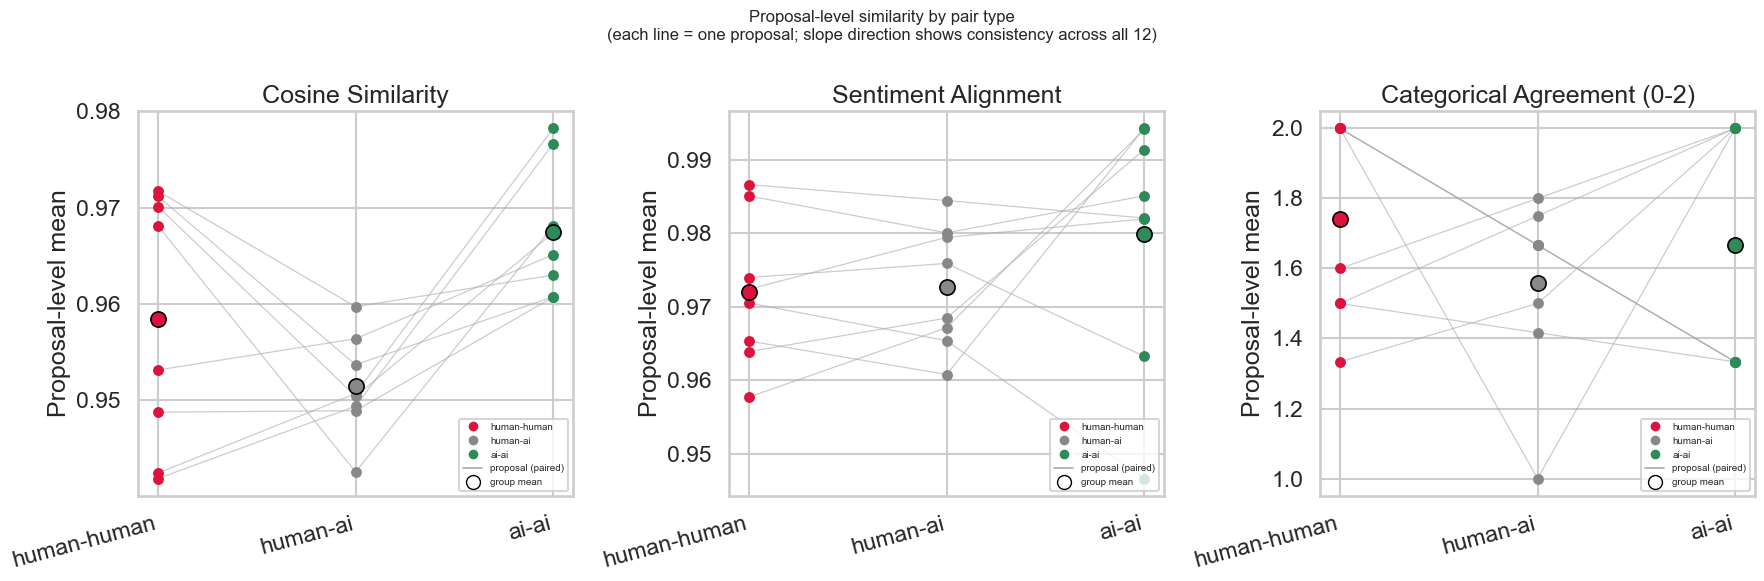

/var/folders/17/4vnbnj_12zv7szz7s0jq3dj80000gn/T/ipykernel_36201/398897531.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=human_ai_by_model_prop, x='ai_model', y=metric,
/var/folders/17/4vnbnj_12zv7szz7s0jq3dj80000gn/T/ipykernel_36201/398897531.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=human_ai_by_model_prop, x='ai_model', y=metric,
/var/folders/17/4vnbnj_12zv7szz7s0jq3dj80000gn/T/ipykernel_36201/398897531.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=human_ai_by_model_prop, x='ai_model', y=metric,


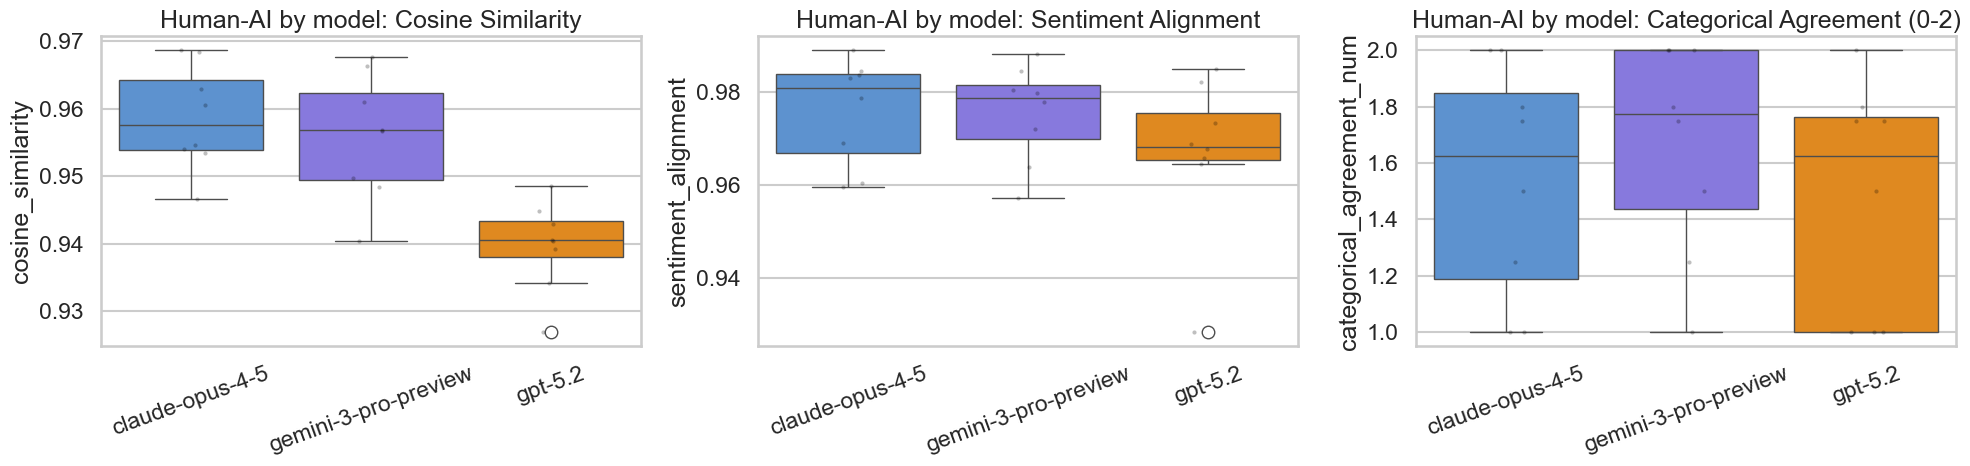

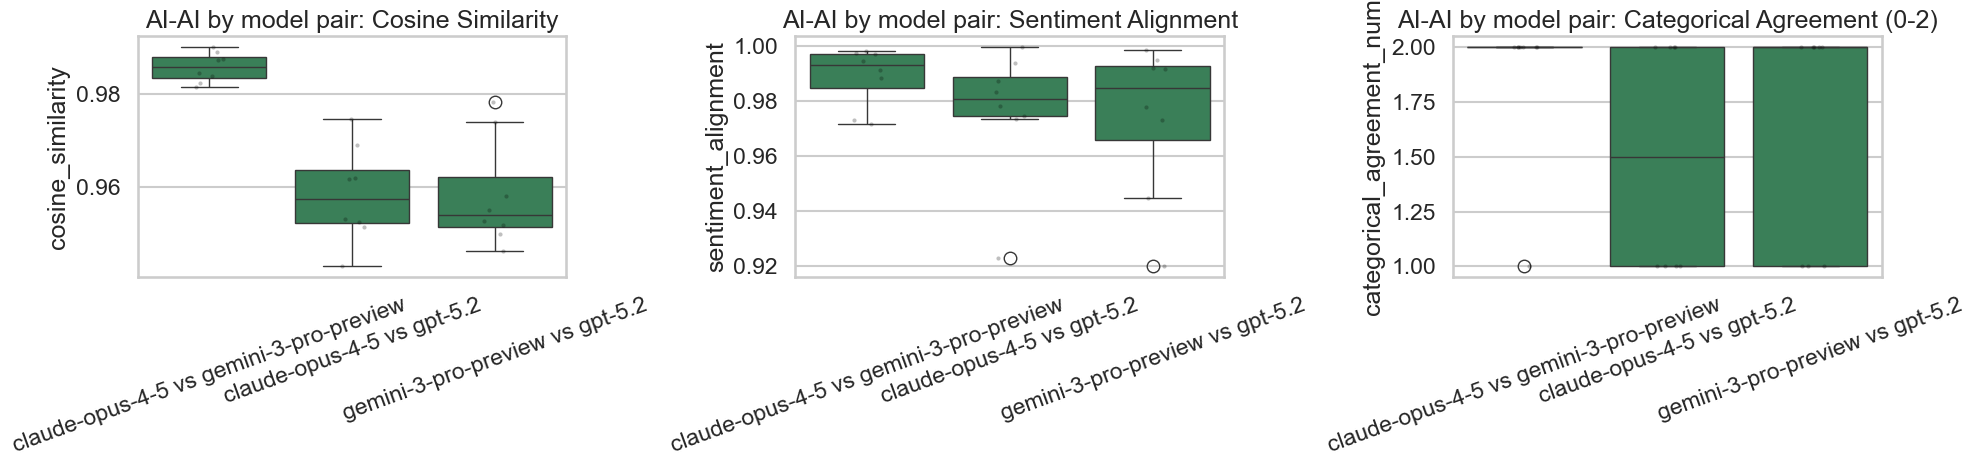

In [10]:
# Paired slope plot (primary): each line = one proposal, connecting its
# proposal-level mean across pair types. Directly shows the paired structure
# used by Wilcoxon (e.g. W=0 means every proposal had the same direction).
#
# Figure 2/3: Boxplots for unpaired model/pair-level breakdowns (appropriate there).

pt_order   = ['human-human', 'human-ai', 'ai-ai']
pt_palette = {'human-human': colors['Human'], 'human-ai': '#888888', 'ai-ai': '#2E8B57'}

# Wide table: one row per proposal, columns per (pair_type x metric)
wide_hh = human_human_prop.set_index('proposal_key')[SIM_METRICS].add_suffix('__human-human')
wide_ha = human_ai_prop.set_index('proposal_key')[SIM_METRICS].add_suffix('__human-ai')
wide_aa = ai_ai_prop.set_index('proposal_key')[SIM_METRICS].add_suffix('__ai-ai')
wide_df = wide_hh.join(wide_ha, how='inner').join(wide_aa, how='inner')

metric_titles = {
    'cosine_similarity':         'Cosine Similarity',
    'sentiment_alignment':       'Sentiment Alignment',
    'categorical_agreement_num': 'Categorical Agreement (0-2)',
}

# --- Figure 1: Paired slope plot ---
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'Proposal-level similarity by pair type\n'
    '(each line = one proposal; slope direction shows consistency across all 12)',
    fontsize=12,
)

for ax, metric in zip(axes, SIM_METRICS):
    for pk, row in wide_df.iterrows():
        ys = [row[f'{metric}__{pt}'] for pt in pt_order]
        ax.plot(range(3), ys, color='#aaaaaa', linewidth=0.9, alpha=0.6, zorder=1)
        for xi, (pt, y) in enumerate(zip(pt_order, ys)):
            ax.scatter(xi, y, color=pt_palette[pt], s=40, zorder=2)
    # Group means as large outlined markers
    for xi, pt in enumerate(pt_order):
        mean = wide_df[f'{metric}__{pt}'].mean()
        ax.scatter(xi, mean, color=pt_palette[pt], s=120, zorder=3,
                   edgecolors='black', linewidths=1.2)
    ax.set_xticks(range(3))
    ax.set_xticklabels(pt_order, rotation=15, ha='right')
    ax.set_title(metric_titles[metric])
    ax.set_ylabel('Proposal-level mean')
    legend_handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=pt_palette[pt],
               markersize=8, label=pt)
        for pt in pt_order
    ] + [
        Line2D([0], [0], color='#aaaaaa', linewidth=1.2, label='proposal (paired)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
               markeredgecolor='black', markersize=10, label='group mean'),
    ]
    ax.legend(handles=legend_handles, fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'quality_similarity_proxy_paired_slopes.png', dpi=200, bbox_inches='tight')
plt.show()

# --- Figure 2: Human-AI breakdown by evaluator model ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
model_order   = sorted(human_ai_by_model_prop['ai_model'].dropna().unique())
model_palette = {m: colors.get(m, '#999999') for m in model_order}
for ax, metric, title in zip(axes, SIM_METRICS, metric_titles.values()):
    sns.boxplot(data=human_ai_by_model_prop, x='ai_model', y=metric,
                order=model_order, ax=ax, palette=model_palette)
    sns.stripplot(data=human_ai_by_model_prop, x='ai_model', y=metric,
                  order=model_order, ax=ax, color='black', alpha=0.25, size=3)
    ax.set_title(f'Human-AI by model: {title}')
    ax.tick_params(axis='x', rotation=20)
    ax.set_xlabel('')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'quality_similarity_human_ai_by_model_proposal_level.png', dpi=200, bbox_inches='tight')
plt.show()

# --- Figure 3: AI-AI breakdown by model pair ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
pair_order = sorted(ai_ai_by_pair_prop['ai_model_pair'].dropna().unique())
for ax, metric, title in zip(axes, SIM_METRICS, metric_titles.values()):
    sns.boxplot(data=ai_ai_by_pair_prop, x='ai_model_pair', y=metric,
                order=pair_order, ax=ax, color='#2E8B57')
    sns.stripplot(data=ai_ai_by_pair_prop, x='ai_model_pair', y=metric,
                  order=pair_order, ax=ax, color='black', alpha=0.25, size=3)
    ax.set_title(f'AI-AI by model pair: {title}')
    ax.tick_params(axis='x', rotation=20)
    ax.set_xlabel('')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'quality_similarity_ai_ai_by_model_pair_proposal_level.png', dpi=200, bbox_inches='tight')
plt.show()


### Interpretation: Similarity Plots

- **Human-human** provides the inter-expert baseline.
- If **human-AI** distribution overlaps strongly with human-human, AI reviews behave more like human proxy ratings.
- If **AI-AI** is much tighter/higher than human-human, AI reviewers may be internally consistent but not necessarily human-aligned.
- In model-specific plots, identify which AI model drives deviation from human baseline.


# R2: How are AI proposals' quality compare to humans (evaluated by AI)

## 10) Proposal-quality analysis dataset (proposal-level means, no duplicated human-all rows)

**Purpose**
Create the main proposal-level scoring dataset for quality comparisons.

**How this is done**
- Average scores across evaluators within each proposal.
- Keep true base groups (`human-y1`, `human-y2`, and each AI author model).
- Construct `human-all` only analytically (not by duplicating rows in source data).

**Why this method is appropriate**
- Proposal-level summaries align with the research question: proposal quality, not individual review idiosyncrasy.
- Avoiding duplicated rows prevents biased evaluator-level analyses and inflated sample counts.


In [11]:
# Purpose:
# Build proposal-level quality dataset and summary stats without contaminating source
# data via duplicated synthetic groups.

QUALITY_METRICS = ['overall_score'] + CRITERIA_ORDER

proposal_scores = (
    ai_df.groupby(['author', 'proposal_id', 'proposal_uid'])[QUALITY_METRICS]
    .mean()
    .reset_index()
)

base_groups = ['human-y1', 'human-y2', 'claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']
proposal_scores = proposal_scores[proposal_scores['author'].isin(base_groups)].copy()


def get_group_values(df_, group_name, metric):
    if group_name == 'human-all':
        return df_[df_['author'].isin(['human-y1', 'human-y2'])][metric].dropna().values
    return df_[df_['author'] == group_name][metric].dropna().values


keep_groups = ['human-y1', 'human-y2', 'human-all', 'claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']

summary_rows = []
for g in keep_groups:
    vals = proposal_scores[proposal_scores['author'].isin(['human-y1', 'human-y2'])]['overall_score'] if g == 'human-all' else proposal_scores[proposal_scores['author'] == g]['overall_score']
    summary_rows.append({
        'group': g,
        'n_proposals': int(vals.notna().sum()),
        'overall_mean': float(vals.mean()),
        'overall_median': float(vals.median()),
        'overall_std': float(vals.std()),
    })

summary_overall_df = pd.DataFrame(summary_rows)
summary_overall_df


,group,n_proposals,overall_mean,overall_median,overall_std
0,human-y1,12,3.280556,3.300000,0.494303
1,human-y2,11,3.442424,3.566667,0.516847
2,human-all,23,3.357971,3.533333,0.500426
3,claude-opus-4-5,23,3.933333,3.966667,0.089893
4,gemini-3-pro-preview,23,3.894203,4.000000,0.343725
5,gpt-5.2,23,3.976812,4.000000,0.080047


### Interpretation: Proposal-Level Summary Dataset

- Check `n_proposals` per group first; unequal group sizes affect power.
- `overall_mean`/`median` provide central tendency; `overall_std` indicates heterogeneity.
- Use this table to contextualize later pairwise tests (e.g., large variance can weaken significance despite mean gaps).


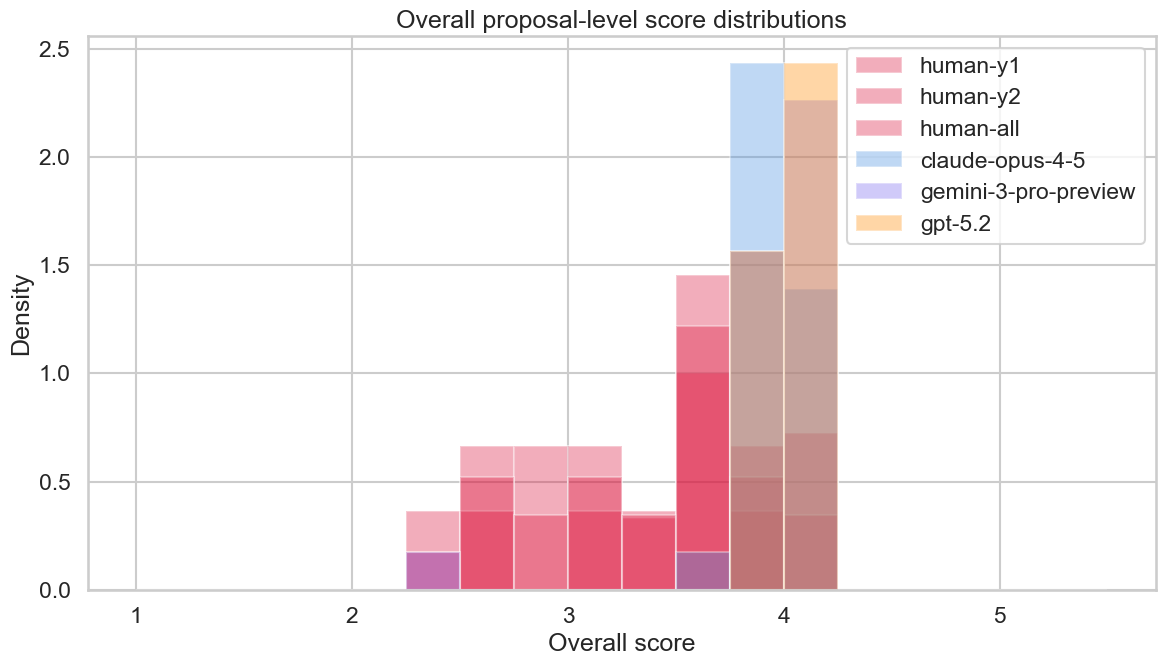

/var/folders/17/4vnbnj_12zv7szz7s0jq3dj80000gn/T/ipykernel_36201/1674528752.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='author_group', y='overall_score', order=keep_groups, palette=palette)


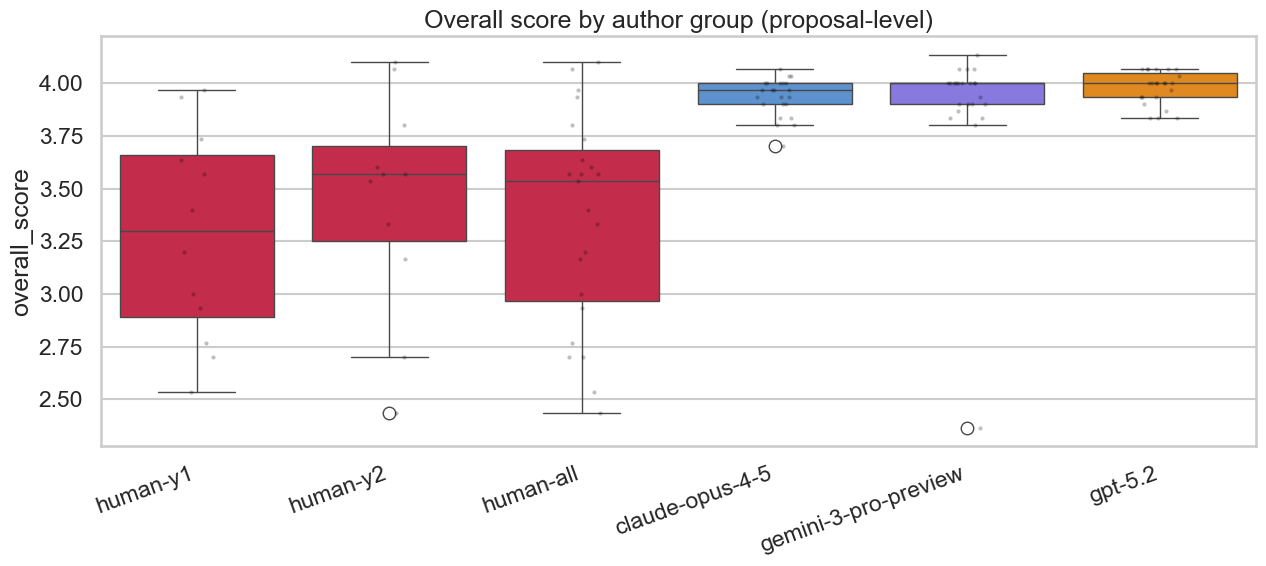

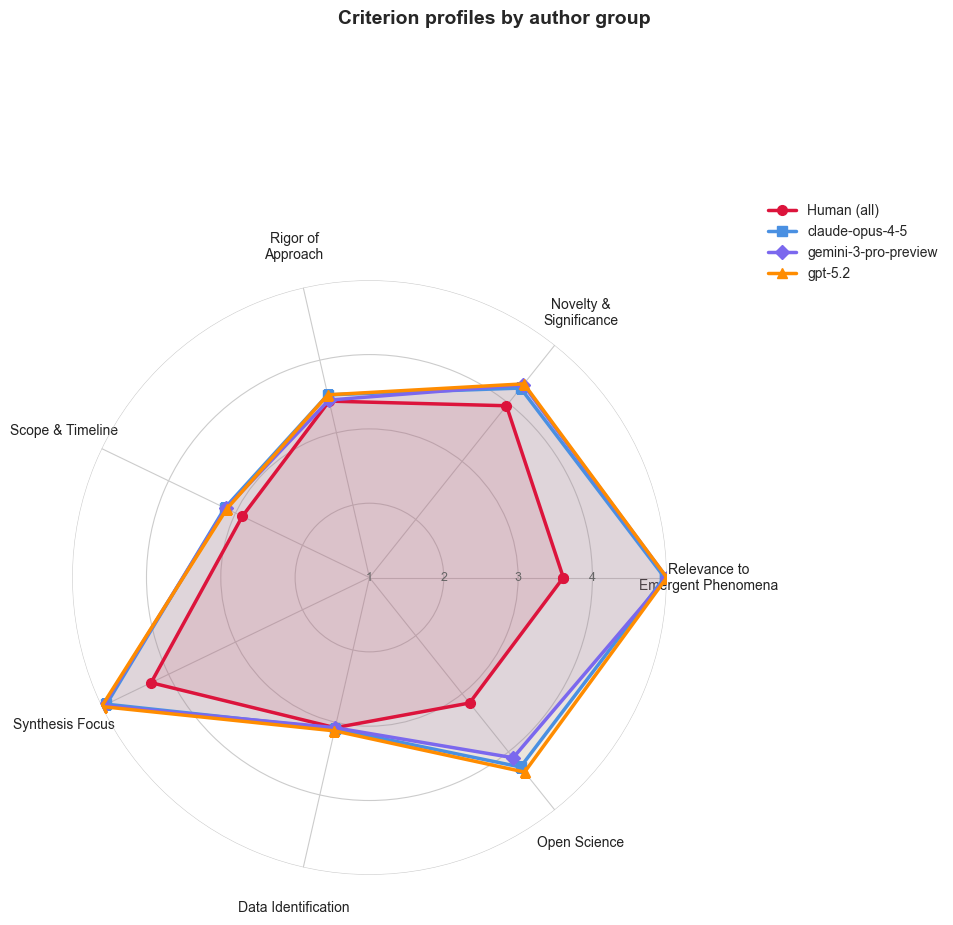

In [12]:
# Purpose:
# Visual diagnostics for quality distributions and criterion profiles.
#
# Note:
# 'human-all' is generated only for comparative plotting convenience.

plot_frames = []
for g in keep_groups:
    if g == 'human-all':
        tmp = proposal_scores[proposal_scores['author'].isin(['human-y1', 'human-y2'])].copy()
    else:
        tmp = proposal_scores[proposal_scores['author'] == g].copy()
    tmp['author_group'] = g
    plot_frames.append(tmp)
plot_df = pd.concat(plot_frames, ignore_index=True)

plt.figure(figsize=(12, 7))
for g in keep_groups:
    s = plot_df.loc[plot_df['author_group'] == g, 'overall_score'].dropna()
    if len(s) == 0:
        continue
    color = colors['Human'] if 'human' in g else colors.get(g, '#999999')
    plt.hist(s, bins=np.arange(1, 5.6, 0.25), alpha=0.35, label=g, color=color, density=True)
plt.xlabel('Overall score')
plt.ylabel('Density')
plt.title('Overall proposal-level score distributions')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'quality_overall_histograms_proposal_level.png', dpi=200, bbox_inches='tight')
plt.show()

plt.figure(figsize=(13, 6))
palette = {g: (colors['Human'] if 'human' in g else colors.get(g, '#999999')) for g in keep_groups}
sns.boxplot(data=plot_df, x='author_group', y='overall_score', order=keep_groups, palette=palette)
sns.stripplot(data=plot_df, x='author_group', y='overall_score', order=keep_groups, color='black', alpha=0.25, size=3)
plt.xticks(rotation=20, ha='right')
plt.title('Overall score by author group (proposal-level)')
plt.xlabel('')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'quality_overall_boxplot_proposal_level.png', dpi=200, bbox_inches='tight')
plt.show()

radar_groups = ['human-all', 'claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']

# Short display labels matching the reference style
radar_labels = {
    'Relevance_to_Emergent_Phenomena': 'Relevance to\nEmergent Phenomena',
    'Novelty_and_Significance':        'Novelty &\nSignificance',
    'Rigor_of_Approach':               'Rigor of\nApproach',
    'Scope_and_Timeline':              'Scope & Timeline',
    'Synthesis_Focus':                 'Synthesis Focus',
    'Data_Identification':             'Data Identification',
    'Open_Science_Commitment':         'Open Science',
}

# Marker styles per group
radar_markers = {
    'human-all':           'o',
    'claude-opus-4-5':     's',
    'gemini-3-pro-preview':'D',
    'gpt-5.2':             '^',
}

radar_legend_names = {
    'human-all':           'Human (all)',
    'claude-opus-4-5':     'claude-opus-4-5',
    'gemini-3-pro-preview':'gemini-3-pro-preview',
    'gpt-5.2':             'gpt-5.2',
}

N = len(CRITERIA_ORDER)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(10, 10), facecolor='white')
ax = fig.add_subplot(111, polar=True, facecolor='white')

# Light gray gridlines only, no outer spine
ax.set_ylim(1, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels([])
ax.yaxis.grid(True, color='#cccccc', linewidth=0.8, linestyle='-')
ax.xaxis.grid(True, color='#cccccc', linewidth=0.8, linestyle='-')
ax.spines['polar'].set_visible(False)

# Scale numbers 1-4 along the first spoke (rightward horizontal)
for tick_val in [1, 2, 3, 4]:
    ax.text(angles[0], tick_val, str(tick_val),
            ha='center', va='center', fontsize=9, color='#666666')

# Plot each group
for g in radar_groups:
    vals = [np.nanmean(get_group_values(proposal_scores, g, c)) for c in CRITERIA_ORDER]
    vals += vals[:1]
    color = colors['Human'] if 'human' in g else colors.get(g, '#999999')
    marker = radar_markers.get(g, 'o')
    ax.plot(angles, vals, linewidth=2.5, color=color,
            marker=marker, markersize=7, markerfacecolor=color,
            label=radar_legend_names.get(g, g))
    ax.fill(angles, vals, alpha=0.12, color=color)

# Axis spoke labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(
    [radar_labels.get(c, c) for c in CRITERIA_ORDER],
    fontsize=10, color='#222222'
)
ax.tick_params(pad=14)

# Legend outside the chart
ax.legend(loc='upper left', bbox_to_anchor=(1.15, 1.15), frameon=False, fontsize=10)

fig.suptitle('Criterion profiles by author group', fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'quality_radar_criteria_proposal_level.png', dpi=200, bbox_inches='tight')
plt.show()


### Interpretation: Quality Distribution Plots

- Histogram/boxplot: inspect central location, spread, and skew across groups.
- Radar chart: identify criteria where human vs AI profiles diverge most.
- Prefer combining visual patterns with statistical tables from Sections 11-12 before drawing conclusions.


## 11) Pairwise quality tests (MW + Cliff's delta + FDR) on proposal-level means

**Purpose**
Identify where quality differences exist between proposal source groups (human cohorts vs AI models), overall and by criterion.

**How this is done**
- Run all pairwise group comparisons for each metric.
- Report Mann-Whitney U, p-value, Cliff's delta, and group means.
- Apply FDR correction within each metric.

**Why this method is appropriate**
- Non-parametric tests are suitable for small and potentially skewed distributions.
- Effect sizes (Cliff's delta) provide magnitude and direction beyond p-values.


In [13]:
# Purpose:
# Pairwise group comparisons for each quality metric, with FDR control.
#
# Two separate comparisons:
#   1. human-y1 vs human-y2  — are the two human cohorts different?
#      Uses base_groups combinations (no human-all, avoids subset/superset overlap).
#   2. human-all vs each AI group — human-vs-AI contrast at full power (n≈23 vs n≈12).
#      human-all is independent of the AI groups, so Mann-Whitney is valid here.

ai_groups = ['claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']

# --- 1) Human cohort comparison: y1 vs y2 ---
cohort_results = []
for metric in QUALITY_METRICS:
    s1 = get_group_values(proposal_scores, 'human-y1', metric)
    s2 = get_group_values(proposal_scores, 'human-y2', metric)
    out = mannwhitney_summary(s1, s2, metric_name=metric)
    out['group1'] = 'human-y1'
    out['group2'] = 'human-y2'
    out['mean_group1'] = np.mean(s1) if len(s1) else np.nan
    out['mean_group2'] = np.mean(s2) if len(s2) else np.nan
    cohort_results.append(out)

human_cohort_df = pd.DataFrame(cohort_results)
human_cohort_df = add_bh_fdr(human_cohort_df, p_col='p_value', group_cols=['metric'])

# --- 2) Human-all vs each AI group ---
vs_ai_results = []
for metric in QUALITY_METRICS:
    s_human = get_group_values(proposal_scores, 'human-all', metric)
    for g in ai_groups:
        s_ai = get_group_values(proposal_scores, g, metric)
        out = mannwhitney_summary(s_human, s_ai, metric_name=metric)
        out['group1'] = 'human-all'
        out['group2'] = g
        out['mean_group1'] = np.mean(s_human) if len(s_human) else np.nan
        out['mean_group2'] = np.mean(s_ai) if len(s_ai) else np.nan
        vs_ai_results.append(out)

vs_ai_df = pd.DataFrame(vs_ai_results)
vs_ai_df = add_bh_fdr(vs_ai_df, p_col='p_value', group_cols=['metric'])

# Also keep a full pairwise table (base_groups only, for AI-vs-AI and other pairs)
pairwise_results = []
for metric in QUALITY_METRICS:
    for g1, g2 in itertools.combinations(base_groups, 2):
        s1 = get_group_values(proposal_scores, g1, metric)
        s2 = get_group_values(proposal_scores, g2, metric)
        out = mannwhitney_summary(s1, s2, metric_name=metric)
        out['group1'] = g1
        out['group2'] = g2
        out['mean_group1'] = np.mean(s1) if len(s1) else np.nan
        out['mean_group2'] = np.mean(s2) if len(s2) else np.nan
        pairwise_results.append(out)

pairwise_df = pd.DataFrame(pairwise_results)
pairwise_df = add_bh_fdr(pairwise_df, p_col='p_value', group_cols=['metric'])

print('1) Human cohort comparison (y1 vs y2):')
display(human_cohort_df.sort_values(['metric', 'q_value']))
print('2) Human-all vs each AI group:')
display(vs_ai_df.sort_values(['metric', 'q_value', 'p_value']))


1) Human cohort comparison (y1 vs y2):


,metric,n_group1,n_group2,u_stat,p_value,cliffs_delta,delta_magnitude,group1,group2,mean_group1,mean_group2,q_value
6,Data_Identification,12,11,56.0,0.548715,-0.151515,small,human-y1,human-y2,3.000000,3.151515,0.548715
2,Novelty_and_Significance,12,11,52.5,0.360258,-0.204545,small,human-y1,human-y2,3.861111,4.060606,0.360258
7,Open_Science_Commitment,12,11,61.0,0.777930,-0.075758,negligible,human-y1,human-y2,3.083333,3.242424,0.777930
1,Relevance_to_Emergent_Phenomena,12,11,55.0,0.509643,-0.166667,small,human-y1,human-y2,3.361111,3.878788,0.509643
3,Rigor_of_Approach,12,11,49.5,0.296657,-0.250000,small,human-y1,human-y2,3.333333,3.545455,0.296657
4,Scope_and_Timeline,12,11,47.5,0.248213,-0.280303,small,human-y1,human-y2,2.805556,3.000000,0.248213
5,Synthesis_Focus,12,11,59.0,0.680398,-0.106061,negligible,human-y1,human-y2,4.305556,4.212121,0.680398
0,overall_score,12,11,55.5,0.537750,-0.159091,small,human-y1,human-y2,3.280556,3.442424,0.537750


2) Human-all vs each AI group:


,metric,n_group1,n_group2,u_stat,p_value,cliffs_delta,delta_magnitude,group1,group2,mean_group1,mean_group2,q_value
18,Data_Identification,23,23,300.5,4.074255e-01,0.136106,negligible,human-all,claude-opus-4-5,3.072464,3.086957,6.488154e-01
19,Data_Identification,23,23,299.0,4.325436e-01,0.130435,negligible,human-all,gemini-3-pro-preview,3.072464,3.072464,6.488154e-01
20,Data_Identification,23,23,282.5,6.876846e-01,0.068053,negligible,human-all,gpt-5.2,3.072464,3.115942,6.876846e-01
8,Novelty_and_Significance,23,23,57.5,1.515940e-07,-0.782609,large,human-all,gpt-5.2,3.956522,4.333333,4.547821e-07
7,Novelty_and_Significance,23,23,67.0,7.288542e-07,-0.746692,large,human-all,gemini-3-pro-preview,3.956522,4.318841,1.093281e-06
6,Novelty_and_Significance,23,23,105.0,9.872047e-05,-0.603025,large,human-all,claude-opus-4-5,3.956522,4.260870,9.872047e-05
23,Open_Science_Commitment,23,23,66.5,1.554773e-06,-0.748582,large,human-all,gpt-5.2,3.159420,4.347826,4.664320e-06
21,Open_Science_Commitment,23,23,80.0,1.476597e-05,-0.697543,large,human-all,claude-opus-4-5,3.159420,4.260870,2.214896e-05
22,Open_Science_Commitment,23,23,102.5,1.839204e-04,-0.612476,large,human-all,gemini-3-pro-preview,3.159420,4.101449,1.839204e-04
4,Relevance_to_Emergent_Phenomena,23,23,11.5,1.908251e-09,-0.956522,large,human-all,gemini-3-pro-preview,3.608696,5.000000,2.862376e-09


### Interpretation: Pairwise Quality Tests

- For each metric, prioritize `q_value` (FDR-adjusted) over raw `p_value`.
- Report both **statistical evidence** (`q_value`) and **practical effect** (`cliffs_delta`, `delta_magnitude`).
- In `vs_human_all`, positive vs negative delta tells whether the comparator tends to score above or below `human-all`.


## 11b) Effect size & significance visualization


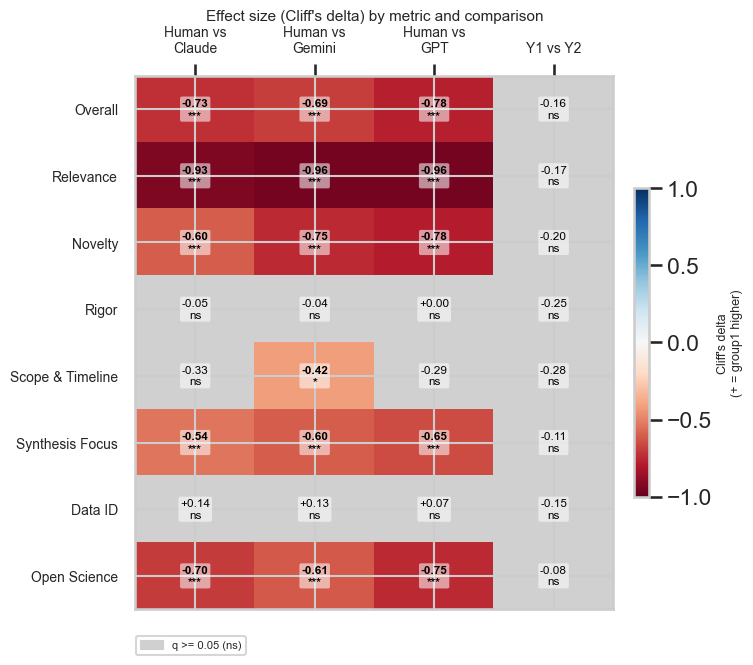

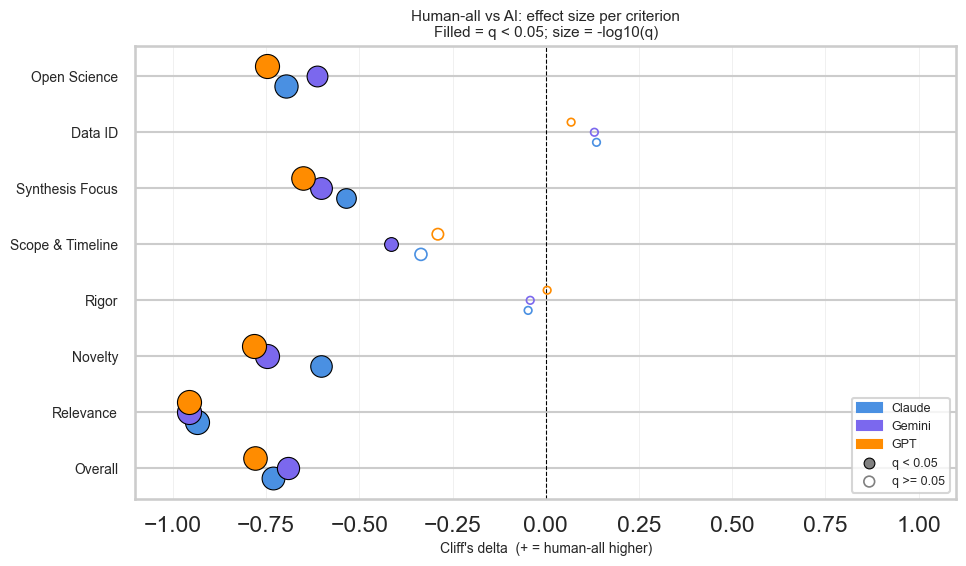

In [14]:
# Panel 1: Effect-size heatmap
#   rows = metrics, columns = comparisons
#   color = Cliff's delta; gray = not significant (q >= 0.05)
#
# Panel 2: Dot plot (human-all vs AI only)
#   x = Cliff's delta, y = metric, color = AI model
#   filled = significant (q < 0.05), hollow = not significant
#   dot size = -log10(q_value)

import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

metric_labels = {
    'overall_score':                  'Overall',
    'Relevance_to_Emergent_Phenomena': 'Relevance',
    'Novelty_and_Significance':        'Novelty',
    'Rigor_of_Approach':              'Rigor',
    'Scope_and_Timeline':             'Scope & Timeline',
    'Synthesis_Focus':                'Synthesis Focus',
    'Data_Identification':            'Data ID',
    'Open_Science_Commitment':        'Open Science',
}
row_order = ['overall_score'] + CRITERIA_ORDER

plot_stats = pd.concat([vs_ai_df, human_cohort_df], ignore_index=True)
col_order  = [
    'human-all vs claude-opus-4-5',
    'human-all vs gemini-3-pro-preview',
    'human-all vs gpt-5.2',
    'human-y1 vs human-y2',
]
plot_stats['col_label'] = plot_stats['group1'] + ' vs ' + plot_stats['group2']

delta_pivot = plot_stats.pivot(index='metric', columns='col_label', values='cliffs_delta').reindex(index=row_order, columns=col_order)
q_pivot     = plot_stats.pivot(index='metric', columns='col_label', values='q_value').reindex(index=row_order, columns=col_order)

readable_rows = [metric_labels.get(m, m) for m in row_order]
readable_cols = ['Human vs\nClaude', 'Human vs\nGemini', 'Human vs\nGPT', 'Y1 vs Y2']

# --- Panel 1: Heatmap ---
fig, ax = plt.subplots(figsize=(8, 7))

delta_arr = delta_pivot.values.astype(float)
q_arr     = q_pivot.values.astype(float)

# Single colormap pass: NaN (non-significant) renders as gray via set_bad()
cmap_hm = plt.cm.RdBu.copy()
cmap_hm.set_bad(color='#d0d0d0')
norm   = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
masked = np.where(q_arr >= 0.05, np.nan, delta_arr)

im = ax.imshow(masked, cmap=cmap_hm, norm=norm, aspect='auto', interpolation='nearest')

# Annotations with white backing box so text is always readable
for ri, metric in enumerate(row_order):
    for ci, col in enumerate(col_order):
        d = delta_arr[ri, ci]
        q = q_arr[ri, ci]
        if np.isnan(d):
            continue
        sig = '***' if q < 0.001 else ('**' if q < 0.01 else ('*' if q < 0.05 else 'ns'))
        label = f'{d:+.2f}\n{sig}'
        txt_color = 'black'
        ax.text(ci, ri, label, ha='center', va='center', fontsize=8.5,
                color=txt_color, fontweight='bold' if q < 0.05 else 'normal',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.55, edgecolor='none'))

ax.set_xticks(range(len(readable_cols)))
ax.set_xticklabels(readable_cols, fontsize=10)
ax.set_yticks(range(len(readable_rows)))
ax.set_yticklabels(readable_rows, fontsize=10)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', pad=6)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("Cliff's delta\n(+ = group1 higher)", fontsize=9)

gray_patch = mpatches.Patch(color='#d0d0d0', label='q >= 0.05 (ns)')
ax.legend(handles=[gray_patch], loc='upper left', bbox_to_anchor=(-0.01, -0.04), fontsize=8)
ax.set_title("Effect size (Cliff's delta) by metric and comparison", fontsize=11, pad=40)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'quality_effect_size_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

# --- Panel 2: Dot plot (human-all vs AI) ---
dot_df = vs_ai_df.copy()
dot_df['metric_label'] = dot_df['metric'].map(metric_labels)
ai_name_map = {'claude-opus-4-5': 'Claude', 'gemini-3-pro-preview': 'Gemini', 'gpt-5.2': 'GPT'}
dot_df['ai_label']    = dot_df['group2'].map(ai_name_map)
dot_df['significant'] = dot_df['q_value'] < 0.05
dot_df['neg_log_q']   = -np.log10(dot_df['q_value'].clip(lower=1e-10))

dot_metric_order = [metric_labels[m] for m in row_order]
dot_model_order  = ['Claude', 'Gemini', 'GPT']
dot_palette = {
    'Claude': colors.get('claude-opus-4-5', '#1f77b4'),
    'Gemini': colors.get('gemini-3-pro-preview', '#ff7f0e'),
    'GPT':    colors.get('gpt-5.2', '#2ca02c'),
}
y_pos     = {m: i for i, m in enumerate(dot_metric_order)}
x_offsets = {'Claude': -0.18, 'Gemini': 0.0, 'GPT': 0.18}

fig, ax = plt.subplots(figsize=(10, 6))

for _, row in dot_df.iterrows():
    ml = row['metric_label']
    al = row['ai_label']
    if pd.isna(ml) or pd.isna(al):
        continue
    yp  = y_pos.get(ml, np.nan) + x_offsets.get(al, 0)
    xp  = row['cliffs_delta']
    sz  = max(30, min(300, row['neg_log_q'] * 60))
    col = dot_palette.get(al, '#999999')
    if row['significant']:
        ax.scatter(xp, yp, s=sz, color=col, edgecolors='black', linewidths=0.8, zorder=3)
    else:
        ax.scatter(xp, yp, s=sz, facecolors='none', edgecolors=col, linewidths=1.2, zorder=3)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(range(len(dot_metric_order)))
ax.set_yticklabels(dot_metric_order, fontsize=10)
ax.set_xlabel("Cliff's delta  (+ = human-all higher)", fontsize=10)
ax.set_xlim(-1.1, 1.1)
ax.set_title("Human-all vs AI: effect size per criterion\nFilled = q < 0.05; size = -log10(q)", fontsize=11)
ax.grid(axis='x', linewidth=0.4, alpha=0.5)

legend_handles = [
    mpatches.Patch(color=dot_palette[m], label=m) for m in dot_model_order
] + [
    plt.scatter([], [], s=60, color='gray', edgecolors='black', linewidths=0.8, label='q < 0.05'),
    plt.scatter([], [], s=60, facecolors='none', edgecolors='gray', linewidths=1.2, label='q >= 0.05'),
]
ax.legend(handles=legend_handles, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'quality_effect_size_dotplot.png', dpi=200, bbox_inches='tight')
plt.show()


## 12) Non-parametric sensitivity check (OPTIONAL)

### Robust inference for key comparisons (bootstrap CI + permutation p)

**Purpose**
Stress-test key human-vs-AI conclusions with distribution-free inference.

**How this is done**
- Bootstrap confidence intervals for mean differences. Resamples the data 2,000 times to estimate a 95% confidence interval around the mean difference in scores. If the CI excludes 0, the difference is practically meaningful.
- Permutation tests for mean-difference significance. Randomly shuffles group labels 5,000 times to build a null distribution of mean differences, then checks how extreme the observed difference is. Produces a p-value without any distributional assumptions.
- FDR correction across permutation p-values.

**Why this method is appropriate**
- Bootstrap CIs quantify uncertainty without strict normality assumptions.
- Permutation tests provide valid small-sample inference under exchangeability.


In [15]:
# Purpose:
# Robustness checks for key human-vs-AI contrasts using bootstrap CIs and
# permutation p-values.

robust_rows = []
for metric in QUALITY_METRICS:
    x = get_group_values(proposal_scores, 'human-all', metric)
    for g in ['claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']:
        y = get_group_values(proposal_scores, g, metric)
        mean_diff, ci_lo, ci_hi = bootstrap_mean_diff_ci(x, y, n_boot=2000, ci=0.95, seed=42)
        p_perm = permutation_p_value_mean_diff(x, y, n_perm=5000, seed=42)
        robust_rows.append({
            'metric': metric,
            'comparison': f'human-all minus {g}',
            'n_human_all': len(x),
            'n_other': len(y),
            'mean_diff': mean_diff,
            'bootstrap_ci_lo': ci_lo,
            'bootstrap_ci_hi': ci_hi,
            'permutation_p_value': p_perm,
        })

robust_quality_df = pd.DataFrame(robust_rows)
robust_quality_df = add_bh_fdr(robust_quality_df, p_col='permutation_p_value', group_cols=['metric'], out_col='permutation_q_value')
robust_quality_df.head(20)


,metric,comparison,n_human_all,n_other,mean_diff,bootstrap_ci_lo,bootstrap_ci_hi,permutation_p_value,permutation_q_value
0,overall_score,human-all minus claude-opus-4-5,23,23,-5.753623e-01,-0.769601,-0.369529,0.000200,0.000200
1,overall_score,human-all minus gemini-3-pro-preview,23,23,-5.362319e-01,-0.773949,-0.276739,0.000200,0.000200
2,overall_score,human-all minus gpt-5.2,23,23,-6.188406e-01,-0.811667,-0.408696,0.000200,0.000200
3,Relevance_to_Emergent_Phenomena,human-all minus claude-opus-4-5,23,23,-1.362319e+00,-1.797101,-0.942029,0.000200,0.000200
4,Relevance_to_Emergent_Phenomena,human-all minus gemini-3-pro-preview,23,23,-1.391304e+00,-1.811594,-0.985507,0.000200,0.000200
5,Relevance_to_Emergent_Phenomena,human-all minus gpt-5.2,23,23,-1.391304e+00,-1.811594,-0.985507,0.000200,0.000200
6,Novelty_and_Significance,human-all minus claude-opus-4-5,23,23,-3.043478e-01,-0.478261,-0.159420,0.000400,0.000400
7,Novelty_and_Significance,human-all minus gemini-3-pro-preview,23,23,-3.623188e-01,-0.521739,-0.231884,0.000200,0.000300
8,Novelty_and_Significance,human-all minus gpt-5.2,23,23,-3.768116e-01,-0.536232,-0.246377,0.000200,0.000300
9,Rigor_of_Approach,human-all minus claude-opus-4-5,23,23,-8.695652e-02,-0.275362,0.101449,0.436713,0.705459


### Interpretation: Robust Inference

- `mean_diff` sign indicates direction (`human-all minus model`).
- If bootstrap CI excludes 0 and permutation `q_value < 0.05`, conclusion is robust.
- If MW and robust tests disagree, treat finding as fragile and report as exploratory.


# R3: Is there any self-preference bias in AI evaluators?

## 13) Evaluator differences (non-duplicated data only)

**Purpose**
Assess whether evaluator models have systematic scoring differences (leniency/stringency).

**How this is done**
- Summarize per-evaluator score distributions.
- Visualize distributions.
- Use Kruskal-Wallis to test overall group differences.

**Why this method is appropriate**
Evaluator drift is a central bias risk in AI-as-judge designs; this provides an explicit diagnostic before interpretation of author-group differences.


In [16]:
# Purpose:
# Quick evaluator-level descriptive statistics on non-duplicated source data.

eval_stats = ai_df.groupby('evaluator')['overall_score'].agg(['count', 'mean', 'median', 'std']).sort_values('mean', ascending=False)
eval_stats


,count,mean,median,std
evaluator,,,,
gemini-3-pro-preview,92,4.198913,4.4,0.495362
claude-opus-4-5,92,3.613043,3.8,0.397303
gpt-5.2,92,3.559783,3.8,0.373301


### Interpretation: Evaluator Descriptives

- Use this table to detect systematic evaluator strictness/leniency before model-comparison claims.
- Large mean/median gaps across evaluators indicate potential judge bias.


/var/folders/17/4vnbnj_12zv7szz7s0jq3dj80000gn/T/ipykernel_36201/667465026.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ai_df, x='evaluator', y='overall_score', palette='Set2')


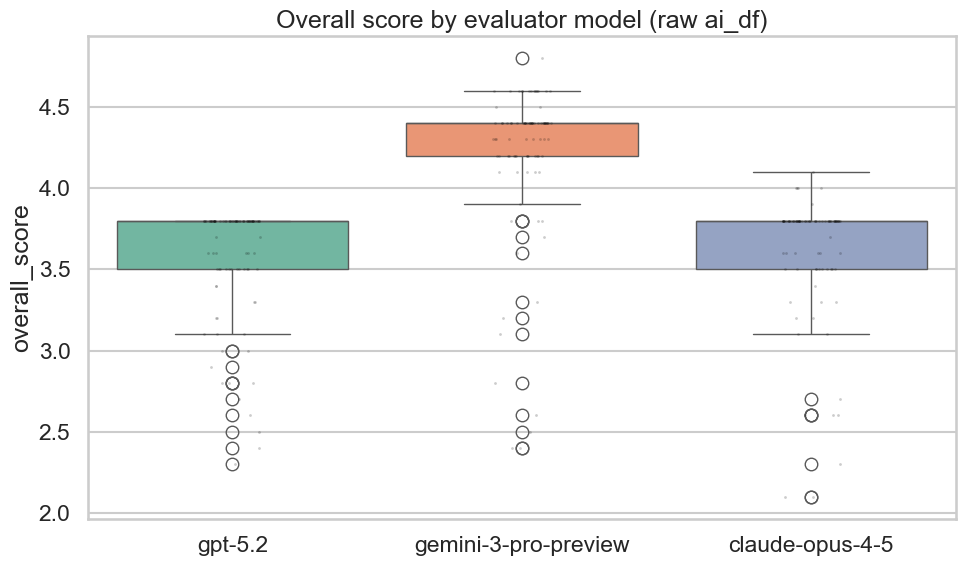

{'kruskal_stat': np.float64(123.30759544786696), 'p_value': np.float64(1.6753126203980714e-27)}


In [17]:
# Purpose:
# Evaluate evaluator distribution differences visually and formally (Kruskal-Wallis).

plt.figure(figsize=(10, 6))
sns.boxplot(data=ai_df, x='evaluator', y='overall_score', palette='Set2')
sns.stripplot(data=ai_df, x='evaluator', y='overall_score', color='black', alpha=0.2, size=2)
plt.title('Overall score by evaluator model (raw ai_df)')
plt.xlabel('')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'quality_overall_by_evaluator_clean.png', dpi=200, bbox_inches='tight')
plt.show()

parts = [ai_df.loc[ai_df['evaluator'] == e, 'overall_score'].dropna().values for e in sorted(ai_df['evaluator'].dropna().unique())]
kw_stat, kw_p = kruskal(*parts)
print({'kruskal_stat': kw_stat, 'p_value': kw_p})


### Interpretation: Evaluator Difference Test

- Kruskal-Wallis `p_value < 0.05` indicates at least one evaluator distribution differs.
- This supports modeling evaluator effects explicitly (Sections 14 and 18).


## 14) AI self-preference tests (overall + criterion-level + proposal controls)

**Purpose**
Test whether AI evaluators prefer proposals generated by their own model.

**How this is done**
1. Compare self vs non-self scores at proposal level (overall).
2. Repeat by criterion to localize bias.
3. Fit fixed-effects regression with proposal controls to isolate self-preference net of proposal difficulty.

**Why this method is appropriate**
Self-preference is a known LLM evaluator bias; combining non-parametric and controlled regression analyses strengthens causal interpretability.


In [18]:
# Purpose:
# Overall self-preference test by evaluator model at proposal level.

ai_authors = ['claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']

sp = ai_df[ai_df['author'].isin(ai_authors) & ai_df['evaluator'].isin(ai_authors)].copy()
sp_prop = (
    sp.groupby(['evaluator', 'author', 'proposal_id'])[QUALITY_METRICS]
    .mean()
    .reset_index()
)
sp_prop['is_self'] = sp_prop['author'] == sp_prop['evaluator']

self_pref_rows = []
for evaluator in ai_authors:
    sub = sp_prop[sp_prop['evaluator'] == evaluator]
    own = sub[sub['is_self']]['overall_score'].dropna()
    other = sub[~sub['is_self']]['overall_score'].dropna()
    out = mannwhitney_summary(own, other, metric_name='overall_score')
    out['evaluator'] = evaluator
    out['mean_self'] = own.mean() if len(own) else np.nan
    out['mean_other'] = other.mean() if len(other) else np.nan
    self_pref_rows.append(out)

self_pref_df = pd.DataFrame(self_pref_rows)
self_pref_df = add_bh_fdr(self_pref_df, p_col='p_value')
self_pref_df


,metric,n_group1,n_group2,u_stat,p_value,cliffs_delta,delta_magnitude,evaluator,mean_self,mean_other,q_value
0,overall_score,23,46,576.0,0.451186,0.088847,negligible,claude-opus-4-5,3.786957,3.726087,0.451186
1,overall_score,23,46,632.0,0.166038,0.194707,small,gemini-3-pro-preview,4.339130,4.367391,0.249058
2,overall_score,23,46,720.5,0.001940,0.362004,medium,gpt-5.2,3.791304,3.654348,0.005819


### Interpretation: Overall Self-Preference

- Compare `mean_self` vs `mean_other` per evaluator.
- `q_value < 0.05` with higher `mean_self` suggests self-favoring bias.
- Opposite direction suggests self-penalization or cross-model preference.


In [19]:
# Purpose:
# Criterion-level self-preference decomposition to identify where bias concentrates.

sp_long = sp_prop.melt(
    id_vars=['evaluator', 'author', 'proposal_id', 'is_self'],
    value_vars=QUALITY_METRICS,
    var_name='metric',
    value_name='score',
).dropna(subset=['score'])

rows = []
for evaluator in ai_authors:
    sube = sp_long[sp_long['evaluator'] == evaluator]
    for metric in QUALITY_METRICS:
        sm = sube[sube['metric'] == metric]
        own = sm[sm['is_self']]['score']
        other = sm[~sm['is_self']]['score']
        out = mannwhitney_summary(own, other, metric_name=metric)
        out['evaluator'] = evaluator
        out['mean_self'] = own.mean() if len(own) else np.nan
        out['mean_other'] = other.mean() if len(other) else np.nan
        rows.append(out)

self_pref_metric_df = pd.DataFrame(rows)
self_pref_metric_df = add_bh_fdr(self_pref_metric_df, p_col='p_value', group_cols=['evaluator'])
self_pref_metric_df.head(20)


,metric,n_group1,n_group2,u_stat,p_value,cliffs_delta,delta_magnitude,evaluator,mean_self,mean_other,q_value
0,overall_score,23,46,576.0,0.451186,0.088847,negligible,claude-opus-4-5,3.786957,3.726087,0.901813
1,Relevance_to_Emergent_Phenomena,23,46,506.0,0.166521,-0.043478,negligible,claude-opus-4-5,4.956522,5.000000,0.666083
2,Novelty_and_Significance,23,46,529.0,1.000000,0.000000,negligible,claude-opus-4-5,4.000000,4.000000,1.000000
3,Rigor_of_Approach,23,46,558.0,0.676360,0.054820,negligible,claude-opus-4-5,3.478261,3.391304,0.901813
4,Scope_and_Timeline,23,46,576.0,0.332250,0.088847,negligible,claude-opus-4-5,2.913043,2.804348,0.886000
5,Synthesis_Focus,23,46,517.5,0.629936,-0.021739,negligible,claude-opus-4-5,4.956522,4.978261,0.901813
6,Data_Identification,23,46,595.0,0.111312,0.124764,negligible,claude-opus-4-5,3.130435,3.000000,0.666083
7,Open_Science_Commitment,23,46,529.0,1.000000,0.000000,negligible,claude-opus-4-5,4.000000,3.956522,1.000000
8,overall_score,23,46,632.0,0.166038,0.194707,small,gemini-3-pro-preview,4.339130,4.367391,0.375398
9,Relevance_to_Emergent_Phenomena,23,46,529.0,1.000000,0.000000,negligible,gemini-3-pro-preview,5.000000,5.000000,1.000000


### Interpretation: Criterion-Level Self-Preference

- Identify which criteria show strongest self-preference (`q_value` + large |delta|).
- A bias concentrated in specific criteria is more actionable than uniform global bias.


## 14b) Self-preference visualization


/var/folders/17/4vnbnj_12zv7szz7s0jq3dj80000gn/T/ipykernel_36201/3225919959.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='Group', y='overall_score', order=['Self', 'Other'],
/var/folders/17/4vnbnj_12zv7szz7s0jq3dj80000gn/T/ipykernel_36201/3225919959.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='Group', y='overall_score', order=['Self', 'Other'],
/var/folders/17/4vnbnj_12zv7szz7s0jq3dj80000gn/T/ipykernel_36201/3225919959.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='Group', y='overal

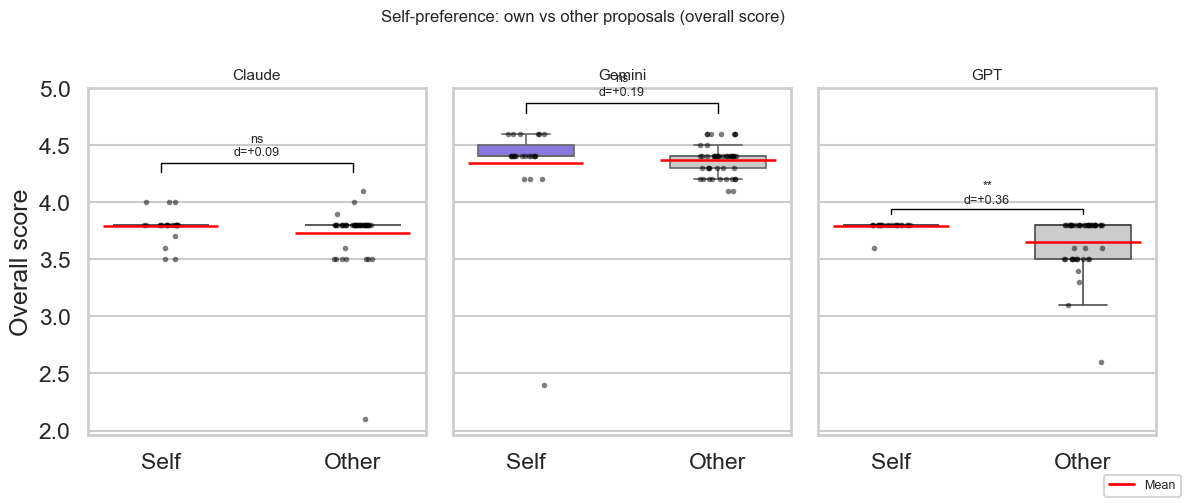

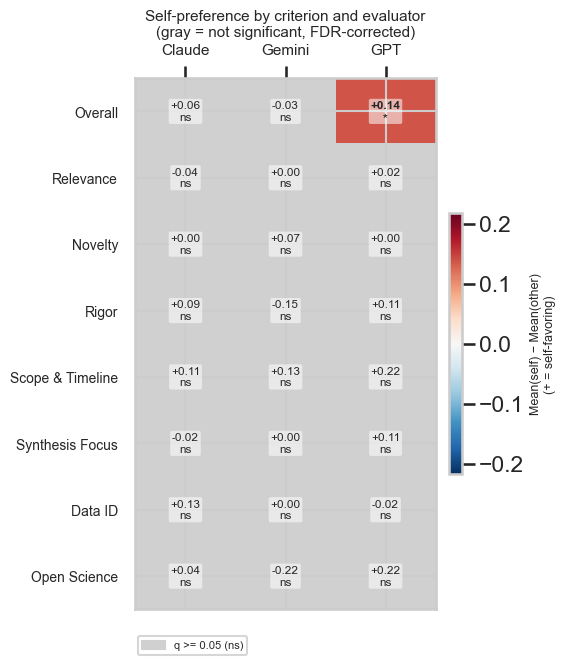

In [20]:
# Two-panel self-preference visualization:
#
# Panel 1 — Faceted strip + box plot (overall score)
#   One column per evaluator model; two groups: self vs other
#   Shows full distribution + mean, annotated with significance
#
# Panel 2 — Criterion-level delta heatmap
#   rows = criteria, columns = evaluator model
#   color = mean_self - mean_other (+ = self-favoring)
#   gray = not significant (q >= 0.05)

import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

ai_name_map = {'claude-opus-4-5': 'Claude', 'gemini-3-pro-preview': 'Gemini', 'gpt-5.2': 'GPT'}
ai_authors_ordered = ['claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']

# --- Panel 1: Faceted strip + box plot ---
fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True)
fig.suptitle('Self-preference: own vs other proposals (overall score)', fontsize=12)

for ax, evaluator in zip(axes, ai_authors_ordered):
    sub = sp_prop[sp_prop['evaluator'] == evaluator][['is_self', 'overall_score']].dropna()
    sub = sub.copy()
    sub['Group'] = sub['is_self'].map({True: 'Self', False: 'Other'})

    grp_color = colors.get(evaluator, '#999999')
    palette = {'Self': grp_color, 'Other': '#cccccc'}

    sns.boxplot(data=sub, x='Group', y='overall_score', order=['Self', 'Other'],
                palette=palette, width=0.5, linewidth=1.2,
                flierprops=dict(marker=''), ax=ax)
    sns.stripplot(data=sub, x='Group', y='overall_score', order=['Self', 'Other'],
                  color='black', alpha=0.5, size=4, jitter=True, ax=ax)

    # Means as horizontal lines
    for xi, grp in enumerate(['Self', 'Other']):
        m = sub[sub['Group'] == grp]['overall_score'].mean()
        ax.hlines(m, xi - 0.3, xi + 0.3, color='red', linewidth=1.8, zorder=5)

    # Significance annotation
    row = self_pref_df[self_pref_df['evaluator'] == evaluator].iloc[0]
    q   = row.get('q_value', row.get('p_value', 1.0))
    sig = '***' if q < 0.001 else ('**' if q < 0.01 else ('*' if q < 0.05 else 'ns'))
    d   = row['cliffs_delta']
    ymax = sub['overall_score'].max()
    yrange = sub['overall_score'].max() - sub['overall_score'].min()
    y_bracket = ymax + yrange * 0.08
    ax.plot([0, 0, 1, 1], [y_bracket, y_bracket + yrange*0.04,
                            y_bracket + yrange*0.04, y_bracket],
            color='black', linewidth=1)
    ax.text(0.5, y_bracket + yrange * 0.06, f'{sig}\nd={d:+.2f}',
            ha='center', va='bottom', fontsize=9)

    ax.set_title(ai_name_map[evaluator], fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Overall score' if ax == axes[0] else '')

red_line = plt.Line2D([0], [0], color='red', linewidth=2, label='Mean')
fig.legend(handles=[red_line], loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'self_pref_strip_overall.png', dpi=200, bbox_inches='tight')
plt.show()

# --- Panel 2: Criterion-level delta heatmap ---
sp_metric = self_pref_metric_df.copy()
sp_metric['delta'] = sp_metric['mean_self'] - sp_metric['mean_other']
sp_metric['evaluator_label'] = sp_metric['evaluator'].map(ai_name_map)

crit_row_order = ['overall_score'] + CRITERIA_ORDER
crit_labels = {
    'overall_score':                  'Overall',
    'Relevance_to_Emergent_Phenomena': 'Relevance',
    'Novelty_and_Significance':        'Novelty',
    'Rigor_of_Approach':              'Rigor',
    'Scope_and_Timeline':             'Scope & Timeline',
    'Synthesis_Focus':                'Synthesis Focus',
    'Data_Identification':            'Data ID',
    'Open_Science_Commitment':        'Open Science',
}
col_labels = [ai_name_map[e] for e in ai_authors_ordered]

delta_grid = sp_metric.pivot(index='metric', columns='evaluator_label', values='delta')\
                       .reindex(index=crit_row_order, columns=col_labels)
q_grid     = sp_metric.pivot(index='metric', columns='evaluator_label', values='q_value')\
                       .reindex(index=crit_row_order, columns=col_labels)

delta_arr = delta_grid.values.astype(float)
q_arr     = q_grid.values.astype(float)

abs_max = np.nanmax(np.abs(delta_arr))
cmap_sp = plt.cm.RdBu_r.copy()   # red = self-favoring (+), blue = other-favoring (-)
cmap_sp.set_bad(color='#d0d0d0')
norm_sp = mcolors.TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)
masked  = np.where(q_arr >= 0.05, np.nan, delta_arr)

fig, ax = plt.subplots(figsize=(6, 7))
im = ax.imshow(masked, cmap=cmap_sp, norm=norm_sp, aspect='auto', interpolation='nearest')

readable_rows = [crit_labels.get(m, m) for m in crit_row_order]
for ri in range(len(crit_row_order)):
    for ci in range(len(col_labels)):
        d = delta_arr[ri, ci]
        q = q_arr[ri, ci]
        if np.isnan(d):
            continue
        sig = '***' if q < 0.001 else ('**' if q < 0.01 else ('*' if q < 0.05 else 'ns'))
        ax.text(ci, ri, f'{d:+.2f}\n{sig}', ha='center', va='center', fontsize=8.5,
                fontweight='bold' if q < 0.05 else 'normal',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.55, edgecolor='none'))

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, fontsize=11)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', pad=6)
ax.set_yticks(range(len(readable_rows)))
ax.set_yticklabels(readable_rows, fontsize=10)

cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
cbar.set_label('Mean(self) − Mean(other)\n(+ = self-favoring)', fontsize=9)

gray_patch = mpatches.Patch(color='#d0d0d0', label='q >= 0.05 (ns)')
ax.legend(handles=[gray_patch], loc='upper left', bbox_to_anchor=(-0.01, -0.04), fontsize=8)
ax.set_title('Self-preference by criterion and evaluator\n(gray = not significant, FDR-corrected)',
             fontsize=11, pad=30)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'self_pref_criterion_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()


#### Do these models rate their own proosals better? How to remove that bias?

The three models go in opposite directions: Claude self-deprecates, GPT strongly self-inflates, Gemini is neutral. This asymmetry is substantively important — it means GPT cannot be treated as an unbiased evaluator of AI-generated proposals in this experiment.

**What the fixed-effects regression does**
The Mann-Whitney test already shows that self-preference exists, but it doesn't rule out a confound: maybe GPT's own proposals just happen to be better, and that's why GPT scores them higher — not because of bias.

The regression controls for this by including proposal fixed effects (C(proposal_uid)):
`score ~ is_self_num * C(metric) + C(evaluator) + C(author) + C(proposal_uid)`
* C(proposal_uid) — gives each proposal its own intercept, absorbing all proposal-specific quality variation. After this, is_self_num only captures the evaluator's behavior change when reviewing their own work, not proposal quality differences.
* C(evaluator) — absorbs evaluator-level severity/leniency (some models score everything higher).
* `is_self_num * C(metric)` — tests whether self-preference concentrates in specific criteria.
* HC3 — heteroscedasticity-robust standard errors, appropriate when residual variance isn't constant.

The coefficient on is_self_num from this model is the net self-preference effect after removing proposal quality as an explanation. If it's still significant here, the bias interpretation is much stronger than what Mann-Whitney alone can support.

One caveat: the model estimates a single average is_self_num effect across all three evaluators. To get model-specific net effects (like the Mann-Whitney table shows), you'd need to add is_self_num * C(evaluator) as an interaction term.


In [21]:
# Purpose:
# Fixed-effects regression to isolate self-preference net of proposal effects.

try:
    import statsmodels.formula.api as smf

    fe_df = sp_long.copy()
    fe_df['proposal_uid'] = fe_df['author'].astype(str) + '::' + fe_df['proposal_id'].astype(str)
    fe_df['is_self_num'] = fe_df['is_self'].astype(int)

    model_self = smf.ols(
        'score ~ is_self_num * C(metric) + C(evaluator) + C(author) + C(proposal_uid)',
        data=fe_df
    ).fit(cov_type='HC3')

    print(model_self.summary().tables[1])
except Exception as e:
    print('statsmodels model skipped:', e)


                                                                                                                                                                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                                                                                                         3.0437      0.064     47.747      0.000       2.919       3.169
C(metric)[T.Novelty_and_Significance]                                                                                                                                             1.2174      0.038     32.113      0.000       1.143       1.292
C(metric)[T.Open_Science_Commitm

/Users/eveyhuang/Documents/NICO/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 87, but rank is 85
  warnings.warn('covariance of constraints does not have full '


### Interpretation: Fixed-Effects Self-Preference Model

- Focus on coefficient for `is_self_num` and interactions with `C(metric)`: 
    - After controlling for proposal quality (via C(proposal_uid)) and evaluator severity (C(evaluator)), an evaluator gives their own proposals +0.33 points more on average than they give other models' proposals. The reference metric here is Data_Identification (it's what's omitted from the dummies), so 0.33 is the self-preference specifically on that criterion.
    - Self-preference is largest on Data_Identification and Rigor, essentially zero on Relevance, and slightly reversed on Synthesis.
- C(evaluator) — overall severity differences
    These are evaluator-level scoring tendencies applied to all proposals, not related to self-preference:
    Gemini scores everything +0.40 higher than Claude (baseline evaluator)
    GPT scores everything −0.20 lower than Claude
    This reflects general leniency/harshness, independent of whose proposal is being evaluated.
- Significant positive terms imply self-preference persists after controlling proposal-level difficulty.
- Non-significant terms suggest observed self-preference may be explained by proposal composition.

**What this adds over the Mann-Whitney results**

The Mann-Whitney showed that GPT self-inflates (+0.99 δ), Claude self-deflates (−0.58 δ), and Gemini is neutral. The regression confirms there is a net positive self-preference (+0.33) after removing the possibility that GPT's own proposals just happen to be better — the proposal fixed effects rule that out. It also decomposes where the bias lives across criteria.
The one limitation: because is_self_num * C(evaluator) isn't in the model, the regression gives you only the average net effect across all three models, not model-specific net effects. The Mann-Whitney table is still the right place to read the per-model story.

## 14c) Fixed-effects regression: forest plot


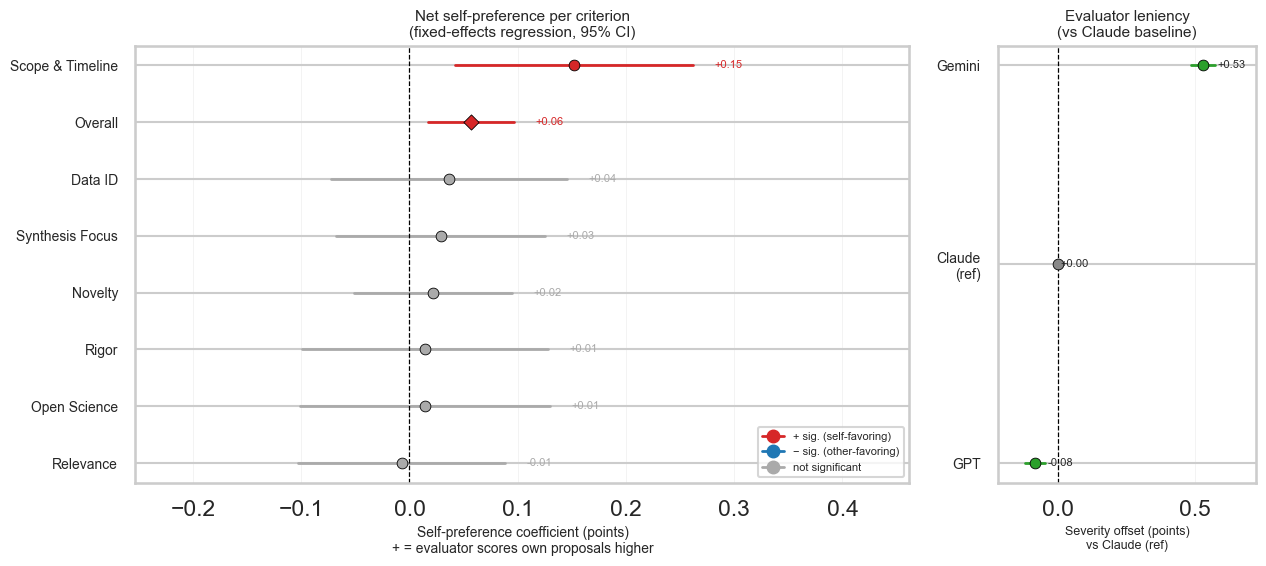

In [22]:
# Forest plot of per-criterion self-preference from the fixed-effects regression.
#
# For each criterion c, the net self-preference is:
#   beta_c = is_self_num + is_self_num:C(metric)[T.c]   (Data_ID is the reference, so beta = is_self_num)
#
# 95% CI uses the model covariance matrix so the uncertainty from both terms is combined correctly:
#   var(beta_c) = var(main) + var(interaction_c) + 2*cov(main, interaction_c)
#
# Separate small panel shows evaluator severity offsets (C(evaluator) main effects).

try:
    import scipy.stats as stats

    crit_labels_reg = {
        'Data_Identification':           'Data ID',
        'Novelty_and_Significance':      'Novelty',
        'Open_Science_Commitment':       'Open Science',
        'Relevance_to_Emergent_Phenomena': 'Relevance',
        'Rigor_of_Approach':             'Rigor',
        'Scope_and_Timeline':            'Scope & Timeline',
        'Synthesis_Focus':               'Synthesis Focus',
        'overall_score':                 'Overall',
    }

    params = model_self.params
    cov    = model_self.cov_params()
    alpha  = 0.05
    z_crit = stats.norm.ppf(1 - alpha / 2)

    main_key = 'is_self_num'
    beta_main = params[main_key]
    var_main  = cov.loc[main_key, main_key]

    # All metrics: Data_ID is reference (interaction absent), others have an interaction term
    all_metrics = ['Data_Identification'] + [
        m for m in CRITERIA_ORDER if m != 'Data_Identification'
    ] + ['overall_score']

    rows_fe = []
    for metric in all_metrics:
        int_key = f'is_self_num:C(metric)[T.{metric}]'
        if int_key in params.index:
            beta_int = params[int_key]
            var_int  = cov.loc[int_key, int_key]
            cov_mi   = cov.loc[main_key, int_key]
            beta = beta_main + beta_int
            se   = (var_main + var_int + 2 * cov_mi) ** 0.5
        else:  # Data_Identification: reference, no interaction term
            beta = beta_main
            se   = var_main ** 0.5
        ci_lo = beta - z_crit * se
        ci_hi = beta + z_crit * se
        sig   = (ci_lo > 0) or (ci_hi < 0)
        rows_fe.append({'metric': metric, 'label': crit_labels_reg[metric],
                         'beta': beta, 'se': se, 'ci_lo': ci_lo, 'ci_hi': ci_hi, 'sig': sig})

    fe_df_plot = pd.DataFrame(rows_fe).sort_values('beta', ascending=True).reset_index(drop=True)

    # Evaluator severity offsets (C(evaluator) main effects)
    ev_keys = [k for k in params.index if k.startswith('C(evaluator)')]
    ev_rows = []
    for k in ev_keys:
        name = k.split('[T.')[1].rstrip(']')
        ai_name_map = {'claude-opus-4-5': 'Claude', 'gemini-3-pro-preview': 'Gemini', 'gpt-5.2': 'GPT'}
        label = ai_name_map.get(name, name)
        b  = params[k]
        se = cov.loc[k, k] ** 0.5
        ev_rows.append({'label': label, 'beta': b,
                         'ci_lo': b - z_crit * se, 'ci_hi': b + z_crit * se})
    # Add Claude as reference (0)
    ev_rows.append({'label': 'Claude\n(ref)', 'beta': 0, 'ci_lo': 0, 'ci_hi': 0})
    ev_df_plot = pd.DataFrame(ev_rows).sort_values('beta').reset_index(drop=True)

    # --- Figure: two-panel layout ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6),
                                    gridspec_kw={'width_ratios': [3, 1]})

    # Panel 1: Per-criterion self-preference forest plot
    for yi, row in fe_df_plot.iterrows():
        col  = '#d62728' if row['sig'] and row['beta'] > 0 else \
               '#1f77b4' if row['sig'] and row['beta'] < 0 else '#aaaaaa'
        ax1.plot([row['ci_lo'], row['ci_hi']], [yi, yi], color=col, linewidth=2, zorder=2)
        marker = 'D' if row['label'] == 'Overall' else 'o'
        ax1.scatter(row['beta'], yi, color=col, s=60, zorder=3,
                    edgecolors='black', linewidths=0.6, marker=marker)
        ax1.text(row['ci_hi'] + 0.02, yi, f"{row['beta']:+.2f}",
                 va='center', fontsize=8, color=col)

    ax1.axvline(0, color='black', linewidth=0.9, linestyle='--')
    ax1.set_yticks(range(len(fe_df_plot)))
    ax1.set_yticklabels(fe_df_plot['label'], fontsize=10)
    ax1.set_xlabel("Self-preference coefficient (points)\n+ = evaluator scores own proposals higher",
                   fontsize=10)
    ax1.set_title("Net self-preference per criterion\n(fixed-effects regression, 95% CI)", fontsize=11)
    ax1.grid(axis='x', linewidth=0.4, alpha=0.4)
    ax1.set_xlim(fe_df_plot['ci_lo'].min() - 0.15, fe_df_plot['ci_hi'].max() + 0.2)

    from matplotlib.lines import Line2D
    legend_h = [
        Line2D([0],[0], color='#d62728', linewidth=2, marker='o', label='+ sig. (self-favoring)'),
        Line2D([0],[0], color='#1f77b4', linewidth=2, marker='o', label='− sig. (other-favoring)'),
        Line2D([0],[0], color='#aaaaaa', linewidth=2, marker='o', label='not significant'),
    ]
    ax1.legend(handles=legend_h, fontsize=8, loc='lower right')

    # Panel 2: Evaluator severity
    for yi, row in ev_df_plot.iterrows():
        is_ref = row['ci_lo'] == row['ci_hi']
        col = '#888888' if is_ref else '#2ca02c'
        if not is_ref:
            ax2.plot([row['ci_lo'], row['ci_hi']], [yi, yi], color=col, linewidth=2, zorder=2)
        ax2.scatter(row['beta'], yi, color=col, s=60, zorder=3,
                    edgecolors='black', linewidths=0.6)
        ax2.text(row['ci_hi'] + 0.01, yi, f"{row['beta']:+.2f}",
                 va='center', fontsize=8)

    ax2.axvline(0, color='black', linewidth=0.9, linestyle='--')
    ax2.set_yticks(range(len(ev_df_plot)))
    ax2.set_yticklabels(ev_df_plot['label'], fontsize=10)
    ax2.set_xlabel('Severity offset (points)\nvs Claude (ref)', fontsize=9)
    ax2.set_title('Evaluator leniency\n(vs Claude baseline)', fontsize=11)
    ax2.grid(axis='x', linewidth=0.4, alpha=0.4)
    ax2.set_xlim(ev_df_plot['ci_lo'].min() - 0.1, ev_df_plot['ci_hi'].max() + 0.15)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'self_pref_regression_forest.png', dpi=200, bbox_inches='tight')
    plt.show()

except NameError:
    print('model_self not available — run the regression cell first.')
except Exception as e:
    print(f'Plot failed: {e}')


# R1: Are AI reviews reliable proxy for humans?

## 15) Proxy validity vs human experts (shared 4-category rubric)

**Purpose**
Evaluate whether AI reviewer outputs are a good proxy for human expert panel judgments.

**How this is done**
- Harmonize both sides onto shared rubric dimensions.
- Compute error metrics (bias, MAE, RMSE) and agreement metrics (Spearman/Kendall).
- Evaluate ranking agreement on overall score.

**Why this method is appropriate**
Proxy validity requires both calibration (low error) and ordering consistency (agreement in ranking), not just similar means.


In [23]:
# Purpose:
# Harmonize human and AI evaluations to shared rubric dimensions and build aligned
# proposal-level panels for proxy validity testing.

human_shared = human_raw.copy()
human_shared['proposal_id'] = human_shared['id'].astype(str)
for col in ['scientific_merit_and_innovation_score', 'feasibility_score', 'data_sources_and_limitations_score', 'open_science_compliance_score']:
    human_shared[col] = pd.to_numeric(human_shared[col], errors='coerce')

human_panel = (
    human_shared.groupby('proposal_id')[[
        'scientific_merit_and_innovation_score',
        'feasibility_score',
        'data_sources_and_limitations_score',
        'open_science_compliance_score',
    ]]
    .mean()
    .reset_index()
    .rename(columns={
        'scientific_merit_and_innovation_score': 'Scientific_Merit_and_Innovation',
        'feasibility_score': 'Feasibility',
        'data_sources_and_limitations_score': 'Data_Sources_and_Limitations',
        'open_science_compliance_score': 'Open_Science_Compliance',
    })
)
human_panel['overall_shared'] = human_panel[SHARED_METRICS_4CAT].mean(axis=1)

ai_y1_shared = ai_df[ai_df['author'] == 'human-y1'].copy()
ai_y1_shared['Scientific_Merit_and_Innovation'] = ai_y1_shared[['Relevance_to_Emergent_Phenomena', 'Novelty_and_Significance', 'Rigor_of_Approach']].mean(axis=1)
ai_y1_shared['Feasibility'] = ai_y1_shared['Scope_and_Timeline']
ai_y1_shared['Data_Sources_and_Limitations'] = ai_y1_shared[['Synthesis_Focus', 'Data_Identification']].mean(axis=1)
ai_y1_shared['Open_Science_Compliance'] = ai_y1_shared['Open_Science_Commitment']
ai_y1_shared['overall_shared'] = ai_y1_shared[SHARED_METRICS_4CAT].mean(axis=1)

ai_to_human_id = mapping_df.set_index('ai_proposal_id')['human_proposal_id'].to_dict()
ai_y1_shared['human_proposal_id'] = ai_y1_shared['proposal_id'].map(ai_to_human_id)
ai_y1_shared = ai_y1_shared.dropna(subset=['human_proposal_id']).copy()
ai_y1_shared['human_proposal_id'] = ai_y1_shared['human_proposal_id'].astype(str)

ai_panel = (
    ai_y1_shared.groupby(['evaluator', 'human_proposal_id'])[
        SHARED_METRICS_4CAT + ['overall_shared']
    ]
    .mean()
    .reset_index()
    .rename(columns={'human_proposal_id': 'proposal_id'})
)

print('Human panel proposals:', human_panel['proposal_id'].nunique())
print('AI panel proposals:', ai_panel['proposal_id'].nunique())

human_panel.head(), ai_panel.head()


Human panel proposals: 12
AI panel proposals: 8


(  proposal_id  Scientific_Merit_and_Innovation  Feasibility  \
 0           1                              4.0     4.333333   
 1          10                              4.3          NaN   
 2          11                              4.0     4.000000   
 3          12                              NaN          NaN   
 4           2                              NaN          NaN   
 
    Data_Sources_and_Limitations  Open_Science_Compliance  overall_shared  
 0                      4.666667                 3.666667        4.166667  
 1                           NaN                      NaN        4.300000  
 2                      3.000000                 5.000000        4.000000  
 3                           NaN                      NaN             NaN  
 4                           NaN                      NaN             NaN  ,
          evaluator proposal_id  Scientific_Merit_and_Innovation  Feasibility  \
 0  claude-opus-4-5          10                         4.000000          3.

### Interpretation: Proxy Data Harmonization Check

- Confirm `Human panel proposals` and `AI panel proposals` counts are as expected.
- Mismatch here indicates linkage or missingness issues that must be resolved before interpreting proxy validity.


In [24]:
# Purpose:
# Compute proxy validity diagnostics:
# - bias / MAE / RMSE (calibration quality)
# - Spearman/Kendall (ordinal agreement)
# - rank agreement for overall selection behavior.

proxy_rows = []
rank_rows = []

for evaluator in sorted(ai_panel['evaluator'].unique()):
    sub_ai = ai_panel[ai_panel['evaluator'] == evaluator].copy()
    merged = sub_ai.merge(human_panel, on='proposal_id', suffixes=('_ai', '_human'))

    for metric in SHARED_METRICS_4CAT + ['overall_shared']:
        a_vals = merged[f'{metric}_ai'].values
        h_vals = merged[f'{metric}_human'].values
        err = a_vals - h_vals

        rho, rho_p = spearmanr(a_vals, h_vals)
        tau, tau_p = kendalltau(a_vals, h_vals)

        proxy_rows.append({
            'evaluator': evaluator,
            'metric': metric,
            'n_proposals': len(merged),
            'bias_mean_error': np.mean(err),
            'mae': np.mean(np.abs(err)),
            'rmse': np.sqrt(np.mean(err ** 2)),
            'spearman_rho': rho,
            'spearman_p': rho_p,
            'kendall_tau': tau,
            'kendall_p': tau_p,
        })

    h_rank = merged['overall_shared_human'].rank(ascending=False)
    a_rank = merged['overall_shared_ai'].rank(ascending=False)
    rrho, rrho_p = spearmanr(h_rank, a_rank)
    rtau, rtau_p = kendalltau(h_rank, a_rank)
    rank_rows.append({
        'evaluator': evaluator,
        'spearman_rank_rho': rrho,
        'spearman_rank_p': rrho_p,
        'kendall_rank_tau': rtau,
        'kendall_rank_p': rtau_p,
        'n_proposals': len(merged),
    })

proxy_validity_df = pd.DataFrame(proxy_rows)
proxy_validity_df = add_bh_fdr(proxy_validity_df, p_col='spearman_p', group_cols=['metric'], out_col='spearman_q')
proxy_validity_df = add_bh_fdr(proxy_validity_df, p_col='kendall_p', group_cols=['metric'], out_col='kendall_q')

rank_agreement_df = pd.DataFrame(rank_rows)
rank_agreement_df = add_bh_fdr(rank_agreement_df, p_col='spearman_rank_p', out_col='spearman_rank_q')
rank_agreement_df = add_bh_fdr(rank_agreement_df, p_col='kendall_rank_p', out_col='kendall_rank_q')

print('Proxy validity table:')
display(proxy_validity_df)
print('Rank agreement table:')
display(rank_agreement_df)


Proxy validity table:


,evaluator,metric,n_proposals,bias_mean_error,mae,rmse,spearman_rho,spearman_p,kendall_tau,kendall_p,spearman_q,kendall_q
0,claude-opus-4-5,Scientific_Merit_and_Innovation,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
1,claude-opus-4-5,Feasibility,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
2,claude-opus-4-5,Data_Sources_and_Limitations,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
3,claude-opus-4-5,Open_Science_Compliance,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
4,claude-opus-4-5,overall_shared,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
5,gemini-3-pro-preview,Scientific_Merit_and_Innovation,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
6,gemini-3-pro-preview,Feasibility,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
7,gemini-3-pro-preview,Data_Sources_and_Limitations,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
8,gemini-3-pro-preview,Open_Science_Compliance,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
9,gemini-3-pro-preview,overall_shared,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0


Rank agreement table:


,evaluator,spearman_rank_rho,spearman_rank_p,kendall_rank_tau,kendall_rank_p,n_proposals,spearman_rank_q,kendall_rank_q
0,claude-opus-4-5,NaN,NaN,NaN,NaN,8,1.0,1.0
1,gemini-3-pro-preview,NaN,NaN,NaN,NaN,8,1.0,1.0
2,gpt-5.2,NaN,NaN,NaN,NaN,8,1.0,1.0


### Interpretation: Proxy Validity Results

- **Bias near 0 + low MAE/RMSE** indicates better calibration to human experts.
- **High Spearman/Kendall** indicates stronger ordering agreement with human panel.
- Use rank table to assess whether AI and human reviewers would select similar top proposals.
- If calibration is poor but rank agreement is high, AI may be useful for triage but not absolute scoring.


## 16) Inter-rater agreement metrics (ICC + optional Krippendorff)

**Purpose**
Quantify reliability across raters in a common framework.

**How this is done**
- ICC(2,1): reliability of single ratings.
- ICC(2,k): reliability of average ratings across raters.
- Optional Krippendorff alpha (ordinal) for mixed-rater robustness with missingness tolerance.

**Why this method is appropriate**
These are standard reliability metrics in review studies and directly address whether ratings are consistently reproducible.


In [25]:
# Purpose:
# Compute ICC reliability metrics across the combined rater panel.

icc_rows = []
for metric in SHARED_METRICS_4CAT + ['overall_shared']:
    panel = human_panel[['proposal_id', metric]].rename(columns={metric: 'human_panel'})

    for evaluator in sorted(ai_panel['evaluator'].unique()):
        sub = ai_panel[ai_panel['evaluator'] == evaluator][['proposal_id', metric]].rename(columns={metric: evaluator})
        panel = panel.merge(sub, on='proposal_id', how='inner')

    rater_cols = ['human_panel'] + sorted(ai_panel['evaluator'].unique().tolist())
    mat = panel[rater_cols].to_numpy(dtype=float)
    icc21, icc2k = icc2_1_2k(mat)

    icc_rows.append({
        'metric': metric,
        'n_proposals': mat.shape[0],
        'n_raters': mat.shape[1],
        'icc_2_1': icc21,
        'icc_2_k': icc2k,
    })

icc_df = pd.DataFrame(icc_rows)
icc_df


,metric,n_proposals,n_raters,icc_2_1,icc_2_k
0,Scientific_Merit_and_Innovation,8,4,NaN,NaN
1,Feasibility,8,4,NaN,NaN
2,Data_Sources_and_Limitations,8,4,NaN,NaN
3,Open_Science_Compliance,8,4,NaN,NaN
4,overall_shared,8,4,NaN,NaN


### Interpretation: ICC Reliability

- ICC(2,1): reliability of a single rater score.
- ICC(2,k): reliability of averaged panel score.
- Rule-of-thumb: <0.5 poor, 0.5-0.75 moderate, 0.75-0.9 good, >0.9 excellent.


## 19) Export tables

This section writes all analysis artifacts (mapping diagnostics, test tables, robustness outputs, bias/proxy/reliability results) to `results/figures/quality/` for downstream reporting and manuscript integration.


In [26]:
# Purpose:
# Persist all analysis outputs for reporting, reproducibility, and manuscript figures/tables.

mapping_df.to_csv(OUTPUT_DIR / 'quality_matching_map_exact_fuzzy.csv', index=False)
pair_df.to_csv(OUTPUT_DIR / 'quality_similarity_pairs.csv', index=False)
sim_stats_overall_df.to_csv(OUTPUT_DIR / 'quality_similarity_mw_cliffs_overall.csv', index=False)
sim_stats_hai_by_model_df.to_csv(OUTPUT_DIR / 'quality_similarity_mw_cliffs_human_ai_by_model.csv', index=False)
sim_stats_aiai_by_pair_df.to_csv(OUTPUT_DIR / 'quality_similarity_mw_cliffs_ai_ai_by_model_pair.csv', index=False)

summary_overall_df.to_csv(OUTPUT_DIR / 'quality_summary_overall_by_author_group.csv', index=False)
pairwise_df.to_csv(OUTPUT_DIR / 'quality_pairwise_mw_cliffs_all_metrics_proposal_level.csv', index=False)
robust_quality_df.to_csv(OUTPUT_DIR / 'quality_robust_bootstrap_permutation_key_comparisons.csv', index=False)

eval_stats.to_csv(OUTPUT_DIR / 'quality_evaluator_overall_stats_clean.csv')
self_pref_df.to_csv(OUTPUT_DIR / 'quality_self_preference_tests_overall.csv', index=False)
self_pref_metric_df.to_csv(OUTPUT_DIR / 'quality_self_preference_tests_by_metric.csv', index=False)

proxy_validity_df.to_csv(OUTPUT_DIR / 'quality_proxy_validity_metrics.csv', index=False)
rank_agreement_df.to_csv(OUTPUT_DIR / 'quality_proxy_rank_agreement.csv', index=False)
icc_df.to_csv(OUTPUT_DIR / 'quality_proxy_icc.csv', index=False)
calibration_df.to_csv(OUTPUT_DIR / 'quality_proxy_calibration_regression.csv', index=False)

print('Saved outputs to:', OUTPUT_DIR)
for p in sorted(OUTPUT_DIR.glob('quality_*')):
    print('-', p.name)


NameError: name 'calibration_df' is not defined

## Notes

- Run this notebook top-to-bottom; dependencies are linear by design.
- Interpretation cells below each result explain what to look for and how to report it.
- For significance decisions, prioritize FDR-adjusted `q_value` over raw `p_value`.
- For practical relevance, report effect size magnitude and direction alongside significance.


## 20) R2 Re-Run Without Self-Evaluator Scores on AI-Authored Proposals

This section reruns the same R2 analyses (Sections 10-12 and the same graph types), with one bias-control rule:
- For AI-authored proposals, remove the score where `evaluator == author`.
- AI proposals are then averaged over the 2 cross-evaluators only.
- Human proposals keep all 3 AI evaluators.


In [27]:
# Purpose:
# Reusable R2 pipeline (Sections 10-12 equivalent):
# - proposal-level summary + hist/box/radar plots
# - pairwise tests with FDR + effect-size visualizations
# - robust bootstrap/permutation sensitivity checks
#
# This function writes scenario-specific outputs by suffixing filenames with `run_tag`.

def run_r2_10_12_pipeline(reviews_df, run_tag, run_label):
    import matplotlib.patches as mpatches
    import matplotlib.colors as mcolors

    local_df = reviews_df.copy()
    local_df['proposal_uid'] = local_df['author'].astype(str) + '::' + local_df['proposal_id'].astype(str)

    quality_metrics = ['overall_score'] + CRITERIA_ORDER
    base_groups = ['human-y1', 'human-y2', 'claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']
    ai_groups = ['claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']
    keep_groups = ['human-y1', 'human-y2', 'human-all', 'claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']

    proposal_scores_local = (
        local_df.groupby(['author', 'proposal_id', 'proposal_uid'])[quality_metrics]
        .mean()
        .reset_index()
    )
    proposal_scores_local = proposal_scores_local[proposal_scores_local['author'].isin(base_groups)].copy()

    def get_vals(group_name, metric):
        if group_name == 'human-all':
            return proposal_scores_local[proposal_scores_local['author'].isin(['human-y1', 'human-y2'])][metric].dropna().values
        return proposal_scores_local[proposal_scores_local['author'] == group_name][metric].dropna().values

    # ---- Section 10 equivalent: summary + plots ----
    summary_rows = []
    for g in keep_groups:
        vals = get_vals(g, 'overall_score')
        summary_rows.append({
            'group': g,
            'n_proposals': int(len(vals)),
            'overall_mean': float(np.mean(vals)) if len(vals) else np.nan,
            'overall_median': float(np.median(vals)) if len(vals) else np.nan,
            'overall_std': float(np.std(vals, ddof=1)) if len(vals) > 1 else np.nan,
        })
    summary_overall_local = pd.DataFrame(summary_rows)

    plot_frames = []
    for g in keep_groups:
        if g == 'human-all':
            tmp = proposal_scores_local[proposal_scores_local['author'].isin(['human-y1', 'human-y2'])].copy()
        else:
            tmp = proposal_scores_local[proposal_scores_local['author'] == g].copy()
        tmp['author_group'] = g
        plot_frames.append(tmp)
    plot_df_local = pd.concat(plot_frames, ignore_index=True)

    # Histogram
    plt.figure(figsize=(12, 7))
    for g in keep_groups:
        s = plot_df_local.loc[plot_df_local['author_group'] == g, 'overall_score'].dropna()
        if len(s) == 0:
            continue
        color = colors['Human'] if 'human' in g else colors.get(g, '#999999')
        plt.hist(s, bins=np.arange(1, 5.6, 0.25), alpha=0.35, label=g, color=color, density=True)
    plt.xlabel('Overall score')
    plt.ylabel('Density')
    plt.title(f'Overall proposal-level score distributions ({run_label})')
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'quality_overall_histograms_proposal_level_{run_tag}.png', dpi=200, bbox_inches='tight')
    plt.show()

    # Boxplot
    plt.figure(figsize=(13, 6))
    palette = {g: (colors['Human'] if 'human' in g else colors.get(g, '#999999')) for g in keep_groups}
    sns.boxplot(data=plot_df_local, x='author_group', y='overall_score', order=keep_groups, palette=palette)
    sns.stripplot(data=plot_df_local, x='author_group', y='overall_score', order=keep_groups, color='black', alpha=0.25, size=3)
    plt.xticks(rotation=20, ha='right')
    plt.title(f'Overall score by author group ({run_label})')
    plt.xlabel('')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'quality_overall_boxplot_proposal_level_{run_tag}.png', dpi=200, bbox_inches='tight')
    plt.show()

    # Radar
    radar_groups = ['human-all', 'claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']
    radar_labels = {
        'Relevance_to_Emergent_Phenomena': 'Relevance to\nEmergent Phenomena',
        'Novelty_and_Significance':        'Novelty &\nSignificance',
        'Rigor_of_Approach':               'Rigor of\nApproach',
        'Scope_and_Timeline':              'Scope & Timeline',
        'Synthesis_Focus':                 'Synthesis Focus',
        'Data_Identification':             'Data Identification',
        'Open_Science_Commitment':         'Open Science',
    }
    radar_markers = {
        'human-all': 'o',
        'claude-opus-4-5': 's',
        'gemini-3-pro-preview': 'D',
        'gpt-5.2': '^',
    }

    angles = np.linspace(0, 2 * np.pi, len(CRITERIA_ORDER), endpoint=False)
    angles = np.concatenate([angles, [angles[0]]])

    plt.figure(figsize=(11, 10))
    ax = plt.subplot(111, polar=True)

    for g in radar_groups:
        vals = np.array([np.mean(get_vals(g, c)) for c in CRITERIA_ORDER], dtype=float)
        vals = np.concatenate([vals, [vals[0]]])
        col = colors['Human'] if 'human' in g else colors.get(g, '#999999')
        ax.plot(angles, vals, linewidth=2.4, label=g, color=col, marker=radar_markers.get(g, 'o'), markersize=6)
        ax.fill(angles, vals, alpha=0.08, color=col)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([radar_labels.get(c, c) for c in CRITERIA_ORDER], fontsize=10)
    ax.set_ylim(1, 5)
    ax.set_title(f'Criterion profiles by author group ({run_label})', pad=22)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'quality_radar_criteria_proposal_level_{run_tag}.png', dpi=200, bbox_inches='tight')
    plt.show()

    # ---- Section 11 equivalent: pairwise tests ----
    cohort_results = []
    for metric in quality_metrics:
        s1 = get_vals('human-y1', metric)
        s2 = get_vals('human-y2', metric)
        out = mannwhitney_summary(s1, s2, metric_name=metric)
        out['group1'] = 'human-y1'
        out['group2'] = 'human-y2'
        out['mean_group1'] = np.mean(s1) if len(s1) else np.nan
        out['mean_group2'] = np.mean(s2) if len(s2) else np.nan
        cohort_results.append(out)

    human_cohort_local = pd.DataFrame(cohort_results)
    human_cohort_local = add_bh_fdr(human_cohort_local, p_col='p_value', group_cols=['metric'])

    vs_ai_results = []
    for metric in quality_metrics:
        s_human = get_vals('human-all', metric)
        for g in ai_groups:
            s_ai = get_vals(g, metric)
            out = mannwhitney_summary(s_human, s_ai, metric_name=metric)
            out['group1'] = 'human-all'
            out['group2'] = g
            out['mean_group1'] = np.mean(s_human) if len(s_human) else np.nan
            out['mean_group2'] = np.mean(s_ai) if len(s_ai) else np.nan
            vs_ai_results.append(out)

    vs_ai_local = pd.DataFrame(vs_ai_results)
    vs_ai_local = add_bh_fdr(vs_ai_local, p_col='p_value', group_cols=['metric'])

    all_pairwise = []
    for metric in quality_metrics:
        for g1, g2 in itertools.combinations(base_groups, 2):
            s1 = get_vals(g1, metric)
            s2 = get_vals(g2, metric)
            out = mannwhitney_summary(s1, s2, metric_name=metric)
            out['group1'] = g1
            out['group2'] = g2
            out['mean_group1'] = np.mean(s1) if len(s1) else np.nan
            out['mean_group2'] = np.mean(s2) if len(s2) else np.nan
            all_pairwise.append(out)

    pairwise_local = pd.DataFrame(all_pairwise)
    pairwise_local = add_bh_fdr(pairwise_local, p_col='p_value', group_cols=['metric'])

    # ---- Section 11b equivalent: effect-size/significance figures ----
    metric_labels = {
        'overall_score': 'Overall',
        'Relevance_to_Emergent_Phenomena': 'Relevance',
        'Novelty_and_Significance': 'Novelty',
        'Rigor_of_Approach': 'Rigor',
        'Scope_and_Timeline': 'Scope & Timeline',
        'Synthesis_Focus': 'Synthesis Focus',
        'Data_Identification': 'Data ID',
        'Open_Science_Commitment': 'Open Science',
    }

    row_order = ['overall_score'] + CRITERIA_ORDER
    plot_stats = pd.concat([vs_ai_local, human_cohort_local], ignore_index=True)
    plot_stats['col_label'] = plot_stats['group1'] + ' vs ' + plot_stats['group2']

    col_order = [
        'human-all vs claude-opus-4-5',
        'human-all vs gemini-3-pro-preview',
        'human-all vs gpt-5.2',
        'human-y1 vs human-y2',
    ]

    delta_pivot = plot_stats.pivot(index='metric', columns='col_label', values='cliffs_delta').reindex(index=row_order, columns=col_order)
    q_pivot = plot_stats.pivot(index='metric', columns='col_label', values='q_value').reindex(index=row_order, columns=col_order)

    readable_rows = [metric_labels.get(m, m) for m in row_order]
    readable_cols = ['Human vs\nClaude', 'Human vs\nGemini', 'Human vs\nGPT', 'Y1 vs Y2']

    fig, ax = plt.subplots(figsize=(8.2, 7.1))
    delta_arr = delta_pivot.values.astype(float)
    q_arr = q_pivot.values.astype(float)

    cmap_hm = plt.cm.RdBu.copy()
    cmap_hm.set_bad(color='#d0d0d0')
    norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
    masked = np.where(q_arr >= 0.05, np.nan, delta_arr)

    im = ax.imshow(masked, cmap=cmap_hm, norm=norm, aspect='auto', interpolation='nearest')

    for ri in range(delta_arr.shape[0]):
        for ci in range(delta_arr.shape[1]):
            d = delta_arr[ri, ci]
            q = q_arr[ri, ci]
            if np.isnan(d):
                continue
            sig = '***' if q < 0.001 else ('**' if q < 0.01 else ('*' if q < 0.05 else 'ns'))
            ax.text(ci, ri, f'{d:+.2f}\n{sig}', ha='center', va='center', fontsize=9,
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.78, pad=1.2))

    ax.set_xticks(np.arange(len(readable_cols)))
    ax.set_xticklabels(readable_cols)
    ax.set_yticks(np.arange(len(readable_rows)))
    ax.set_yticklabels(readable_rows)
    ax.set_title(f"Effect Sizes (Cliff's delta) with FDR significance ({run_label})")

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Cliff's delta")

    nonsig_patch = mpatches.Patch(color='#d0d0d0', label='q >= 0.05 (not significant)')
    ax.legend(handles=[nonsig_patch], loc='upper left', bbox_to_anchor=(0, -0.08), frameon=False)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'quality_effectsize_heatmap_{run_tag}.png', dpi=220, bbox_inches='tight')
    plt.show()

    # Dot plot (human-all vs AI only)
    dot_df = vs_ai_local.copy()
    dot_df = dot_df[dot_df['group1'] == 'human-all'].copy()
    dot_df['metric_label'] = dot_df['metric'].map(metric_labels)
    dot_df['q_plot'] = dot_df['q_value'].clip(lower=1e-12)
    dot_df['dot_size'] = 40 + 45 * (-np.log10(dot_df['q_plot']))
    dot_df['sig'] = dot_df['q_value'] < 0.05

    metric_order = [metric_labels.get(m, m) for m in row_order][::-1]

    plt.figure(figsize=(10.5, 6.8))
    for g in ai_groups:
        sub = dot_df[dot_df['group2'] == g]
        yvals = [metric_order.index(m) for m in sub['metric_label']]
        face = colors.get(g, '#888888')
        plt.scatter(
            sub['cliffs_delta'],
            yvals,
            s=sub['dot_size'],
            c=face,
            edgecolors='black',
            linewidths=0.7,
            alpha=0.88,
            label=g,
            marker='o',
        )
        nonsig = sub[~sub['sig']]
        if len(nonsig) > 0:
            y_ns = [metric_order.index(m) for m in nonsig['metric_label']]
            plt.scatter(
                nonsig['cliffs_delta'],
                y_ns,
                s=nonsig['dot_size'],
                facecolors='none',
                edgecolors='black',
                linewidths=1.1,
                marker='o',
            )

    plt.axvline(0, color='black', linestyle='--', linewidth=1)
    plt.yticks(np.arange(len(metric_order)), metric_order)
    plt.xlabel("Cliff's delta (human-all minus AI model)")
    plt.title(f'Human-vs-AI Effect Sizes by Metric ({run_label})')
    plt.legend(title='AI Model', loc='lower right')
    plt.grid(axis='x', linestyle=':', alpha=0.4)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'quality_effectsize_dotplot_{run_tag}.png', dpi=220, bbox_inches='tight')
    plt.show()

    # ---- Section 12 equivalent: robust checks ----
    robust_rows = []
    for metric in quality_metrics:
        x = get_vals('human-all', metric)
        for g in ai_groups:
            y = get_vals(g, metric)
            mean_diff, ci_lo, ci_hi = bootstrap_mean_diff_ci(x, y, n_boot=2000, ci=0.95, seed=42)
            p_perm = permutation_p_value_mean_diff(x, y, n_perm=5000, seed=42)
            robust_rows.append({
                'metric': metric,
                'comparison': f'human-all minus {g}',
                'n_human_all': len(x),
                'n_other': len(y),
                'mean_diff': mean_diff,
                'bootstrap_ci_lo': ci_lo,
                'bootstrap_ci_hi': ci_hi,
                'permutation_p_value': p_perm,
            })

    robust_local = pd.DataFrame(robust_rows)
    robust_local = add_bh_fdr(robust_local, p_col='permutation_p_value', group_cols=['metric'], out_col='permutation_q_value')

    # Save scenario-specific tables
    summary_overall_local.to_csv(OUTPUT_DIR / f'quality_summary_overall_by_author_group_{run_tag}.csv', index=False)
    human_cohort_local.to_csv(OUTPUT_DIR / f'quality_human_cohort_mw_cliffs_{run_tag}.csv', index=False)
    vs_ai_local.to_csv(OUTPUT_DIR / f'quality_vs_ai_mw_cliffs_{run_tag}.csv', index=False)
    pairwise_local.to_csv(OUTPUT_DIR / f'quality_pairwise_mw_cliffs_all_metrics_{run_tag}.csv', index=False)
    robust_local.to_csv(OUTPUT_DIR / f'quality_robust_bootstrap_permutation_{run_tag}.csv', index=False)

    print(f'[{run_label}] proposal-level N by group:')
    display(summary_overall_local)

    print(f'[{run_label}] human-all vs AI tests (FDR-adjusted):')
    display(vs_ai_local.sort_values(['metric', 'q_value', 'p_value']))

    print(f'[{run_label}] robust sensitivity (head):')
    display(robust_local.head(20))

    return {
        'proposal_scores': proposal_scores_local,
        'summary_overall': summary_overall_local,
        'human_cohort': human_cohort_local,
        'vs_ai': vs_ai_local,
        'pairwise': pairwise_local,
        'robust': robust_local,
        'plot_df': plot_df_local,
    }


Rows removed (AI self-evaluations): 69
Remaining rows: 207
Remaining evaluator counts by author (AI authors should each have 2 evaluators/proposal):


evaluator,claude-opus-4-5,gemini-3-pro-preview,gpt-5.2
author,,,
claude-opus-4-5,0,23,23
gemini-3-pro-preview,23,0,23
gpt-5.2,23,23,0


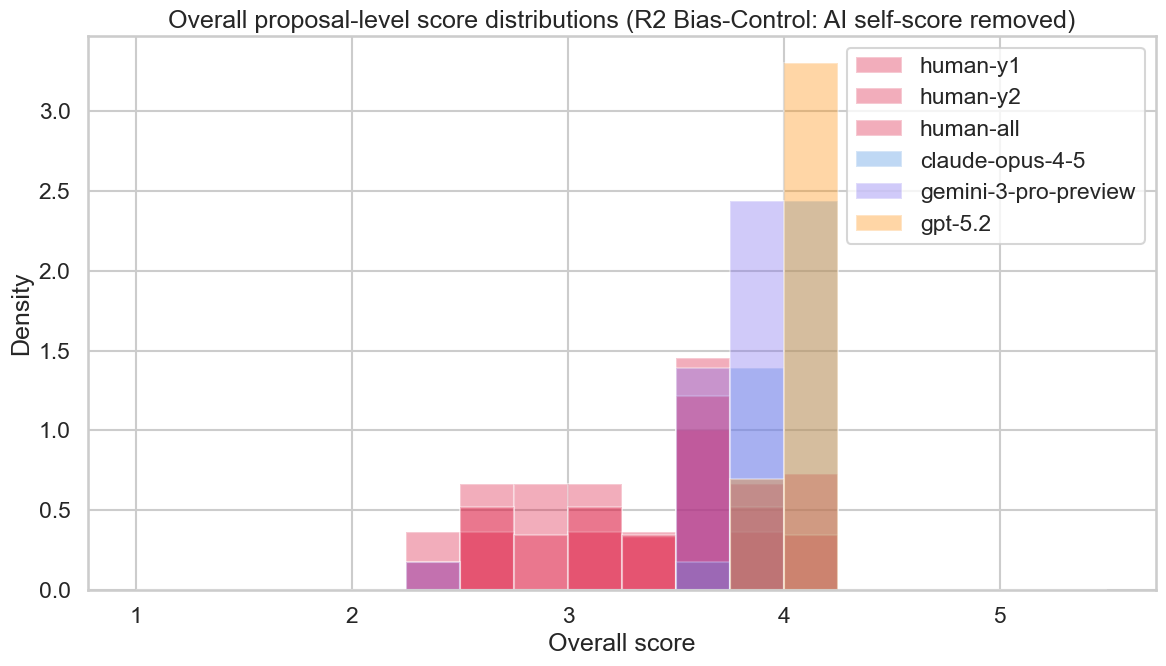

/var/folders/17/4vnbnj_12zv7szz7s0jq3dj80000gn/T/ipykernel_36201/645670658.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df_local, x='author_group', y='overall_score', order=keep_groups, palette=palette)


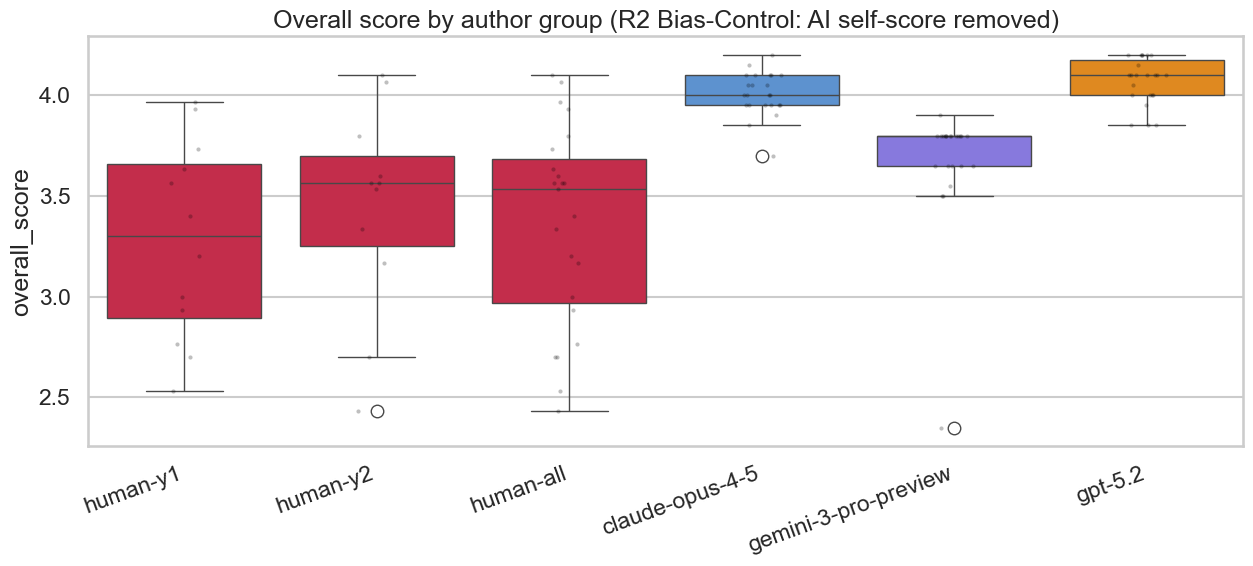

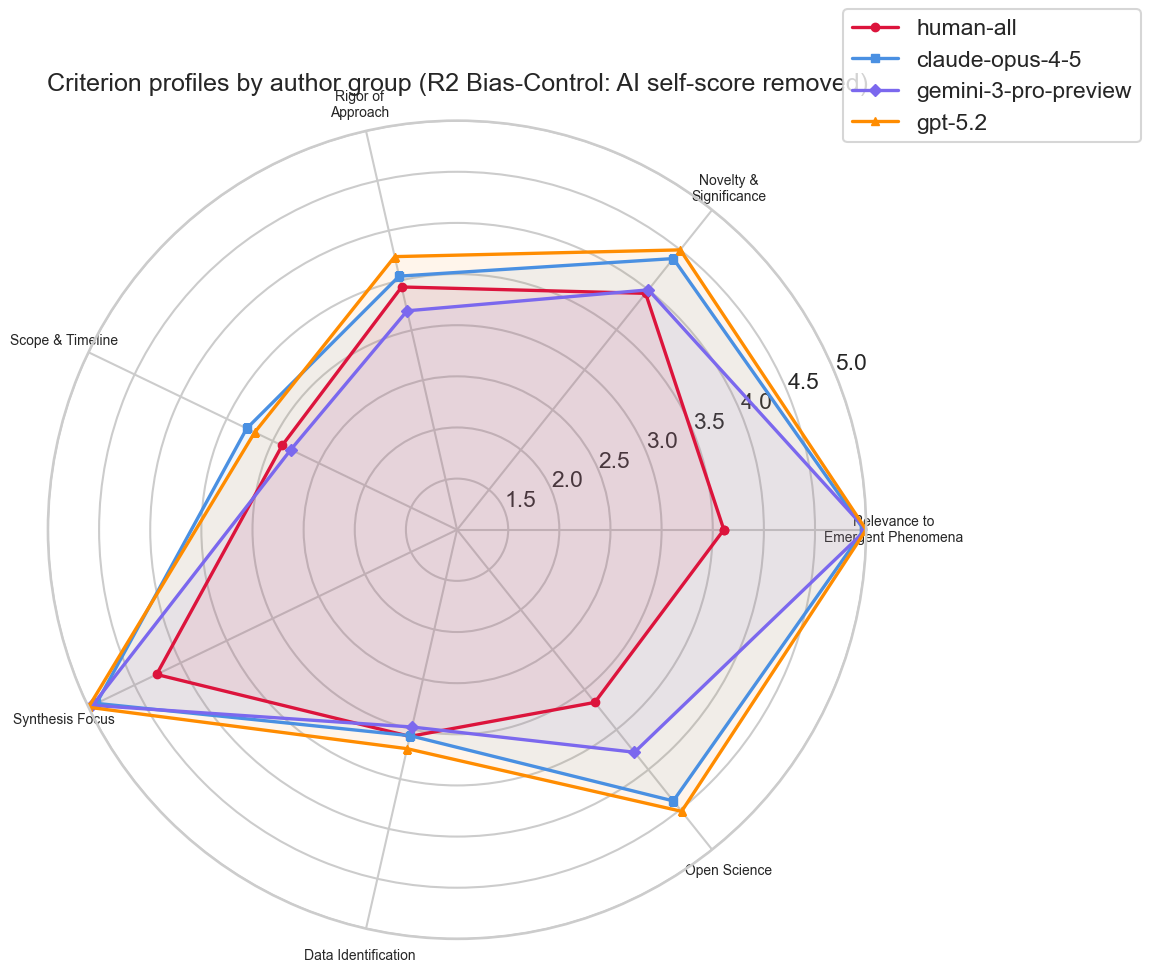

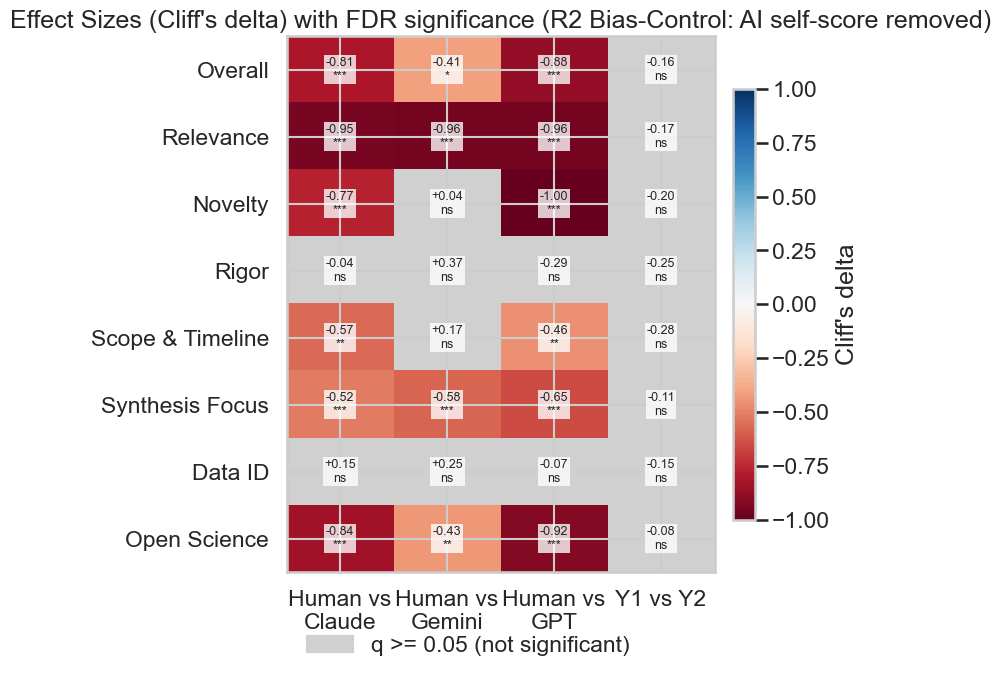

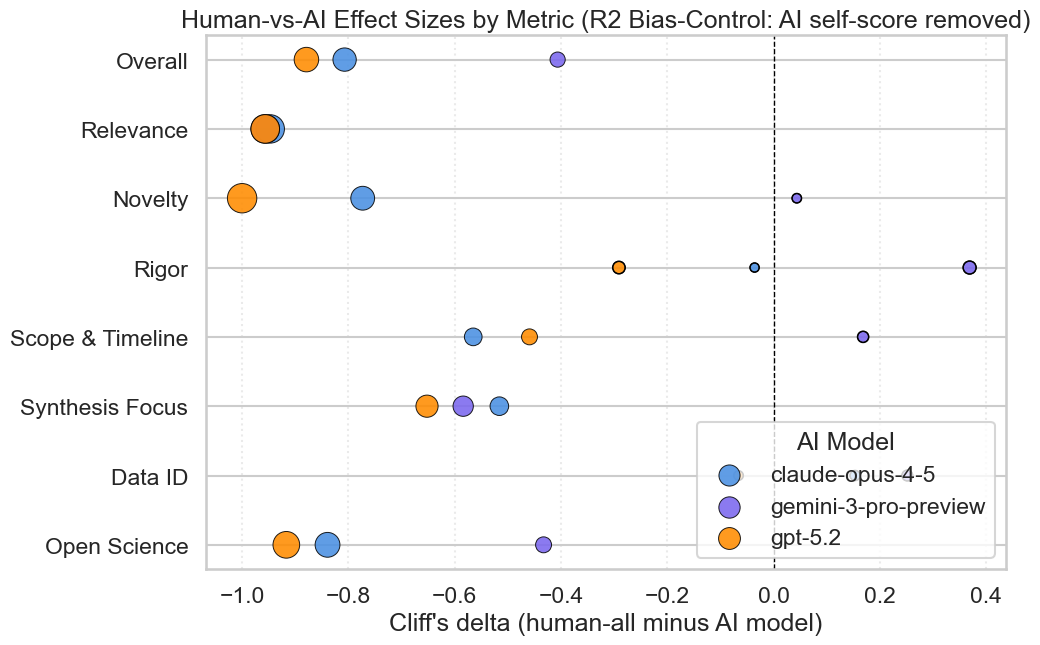

[R2 Bias-Control: AI self-score removed] proposal-level N by group:


,group,n_proposals,overall_mean,overall_median,overall_std
0,human-y1,12,3.280556,3.300000,0.494303
1,human-y2,11,3.442424,3.566667,0.516847
2,human-all,23,3.357971,3.533333,0.500426
3,claude-opus-4-5,23,4.006522,4.000000,0.107982
4,gemini-3-pro-preview,23,3.671739,3.800000,0.308157
5,gpt-5.2,23,4.069565,4.100000,0.115541


[R2 Bias-Control: AI self-score removed] human-all vs AI tests (FDR-adjusted):


,metric,n_group1,n_group2,u_stat,p_value,cliffs_delta,delta_magnitude,group1,group2,mean_group1,mean_group2,q_value
19,Data_Identification,23,23,331.0,1.161859e-01,0.251418,small,human-all,gemini-3-pro-preview,3.072464,2.978261,3.485578e-01
18,Data_Identification,23,23,305.0,3.458478e-01,0.153119,small,human-all,claude-opus-4-5,3.072464,3.065217,5.187717e-01
20,Data_Identification,23,23,247.0,7.011231e-01,-0.066163,negligible,human-all,gpt-5.2,3.072464,3.195652,7.011231e-01
8,Novelty_and_Significance,23,23,0.0,2.856850e-10,-1.000000,large,human-all,gpt-5.2,3.956522,4.500000,8.570549e-10
6,Novelty_and_Significance,23,23,60.0,1.519453e-06,-0.773157,large,human-all,claude-opus-4-5,3.956522,4.391304,2.279180e-06
7,Novelty_and_Significance,23,23,276.0,7.268088e-01,0.043478,negligible,human-all,gemini-3-pro-preview,3.956522,4.000000,7.268088e-01
23,Open_Science_Commitment,23,23,22.0,1.631323e-08,-0.916824,large,human-all,gpt-5.2,3.159420,4.521739,4.893969e-08
21,Open_Science_Commitment,23,23,42.5,4.179447e-07,-0.839319,large,human-all,claude-opus-4-5,3.159420,4.391304,6.269171e-07
22,Open_Science_Commitment,23,23,150.0,9.199465e-03,-0.432892,medium,human-all,gemini-3-pro-preview,3.159420,3.782609,9.199465e-03
4,Relevance_to_Emergent_Phenomena,23,23,11.5,1.908251e-09,-0.956522,large,human-all,gemini-3-pro-preview,3.608696,5.000000,2.862376e-09


[R2 Bias-Control: AI self-score removed] robust sensitivity (head):


,metric,comparison,n_human_all,n_other,mean_diff,bootstrap_ci_lo,bootstrap_ci_hi,permutation_p_value,permutation_q_value
0,overall_score,human-all minus claude-opus-4-5,23,23,-0.648551,-8.427717e-01,-0.437663,0.000200,0.000300
1,overall_score,human-all minus gemini-3-pro-preview,23,23,-0.313768,-5.464493e-01,-0.067373,0.013797,0.013797
2,overall_score,human-all minus gpt-5.2,23,23,-0.711594,-9.080072e-01,-0.498533,0.000200,0.000300
3,Relevance_to_Emergent_Phenomena,human-all minus claude-opus-4-5,23,23,-1.369565,-1.797101e+00,-0.956341,0.000200,0.000200
4,Relevance_to_Emergent_Phenomena,human-all minus gemini-3-pro-preview,23,23,-1.391304,-1.811594e+00,-0.985507,0.000200,0.000200
5,Relevance_to_Emergent_Phenomena,human-all minus gpt-5.2,23,23,-1.391304,-1.811594e+00,-0.985507,0.000200,0.000200
6,Novelty_and_Significance,human-all minus claude-opus-4-5,23,23,-0.434783,-6.159420e-01,-0.275181,0.000200,0.000300
7,Novelty_and_Significance,human-all minus gemini-3-pro-preview,23,23,-0.043478,-2.028986e-01,0.086957,0.555289,0.555289
8,Novelty_and_Significance,human-all minus gpt-5.2,23,23,-0.543478,-7.028986e-01,-0.413043,0.000200,0.000300
9,Rigor_of_Approach,human-all minus claude-opus-4-5,23,23,-0.108696,-2.898551e-01,0.065217,0.286143,0.286143


In [28]:
# Build cross-evaluator-only dataset for AI-authored proposals.
# Rule:
# - AI-authored proposals: drop evaluator==author (remove self-review).
# - Human-authored proposals: keep all 3 AI evaluators.

ai_authors = ['claude-opus-4-5', 'gemini-3-pro-preview', 'gpt-5.2']

self_mask = ai_df['author'].isin(ai_authors) & (ai_df['evaluator'] == ai_df['author'])
ai_df_cross_eval_only = ai_df.loc[~self_mask].copy()

print('Rows removed (AI self-evaluations):', int(self_mask.sum()))
print('Remaining rows:', len(ai_df_cross_eval_only))
print('Remaining evaluator counts by author (AI authors should each have 2 evaluators/proposal):')
display(
    ai_df_cross_eval_only[ai_df_cross_eval_only['author'].isin(ai_authors)]
    .groupby(['author', 'evaluator'])
    .size()
    .unstack(fill_value=0)
)

r2_cross_eval_results = run_r2_10_12_pipeline(
    reviews_df=ai_df_cross_eval_only,
    run_tag='cross_eval_only',
    run_label='R2 Bias-Control: AI self-score removed',
)


### Interpretation: R2 Bias-Control Re-Run

- Compare these outputs to baseline R2.
- If AI-vs-human differences shrink notably, self-evaluator inflation contributed materially.
- If conclusions are stable, R2 findings are robust to this self-preference bias control.


## 21) R2 Re-Run With Gpt Evaluator

This section reruns the same R2 analyses (10-12 + same graph types) using only Gemini-generated reviews for every proposal source (human and AI).


Rows retained (Gemini-only): 92
Proposal counts by author in Gemini-only set:


author
claude-opus-4-5         23
gemini-3-pro-preview    23
gpt-5.2                 23
human-y1                12
human-y2                11
Name: proposal_id, dtype: int64

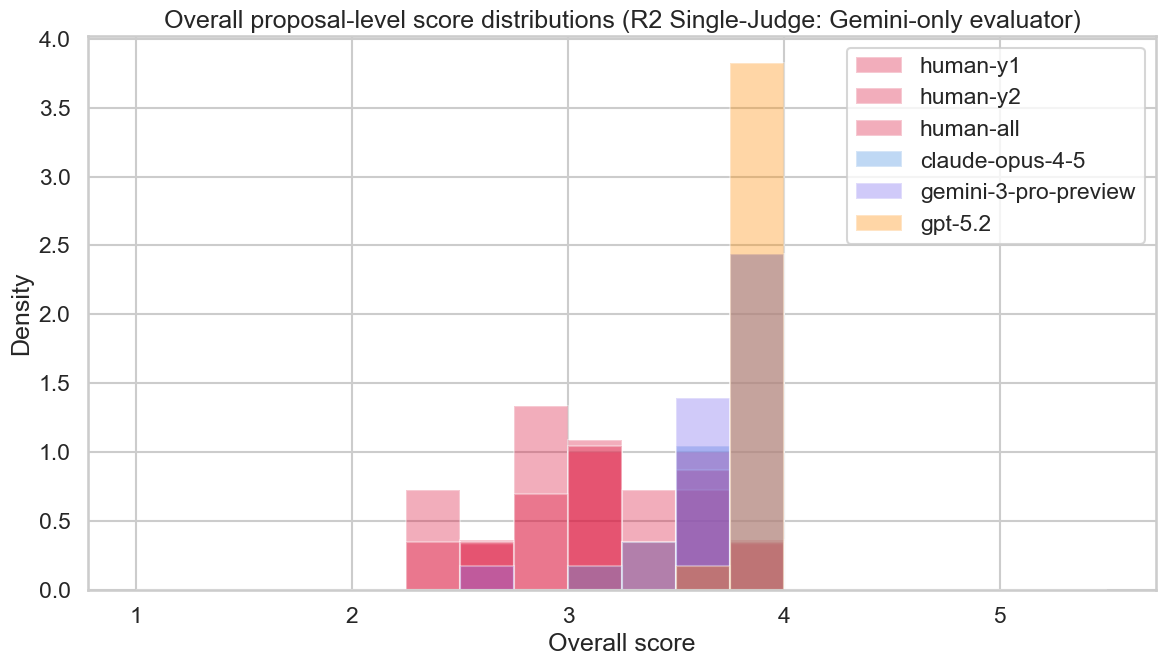

/var/folders/17/4vnbnj_12zv7szz7s0jq3dj80000gn/T/ipykernel_36201/645670658.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df_local, x='author_group', y='overall_score', order=keep_groups, palette=palette)


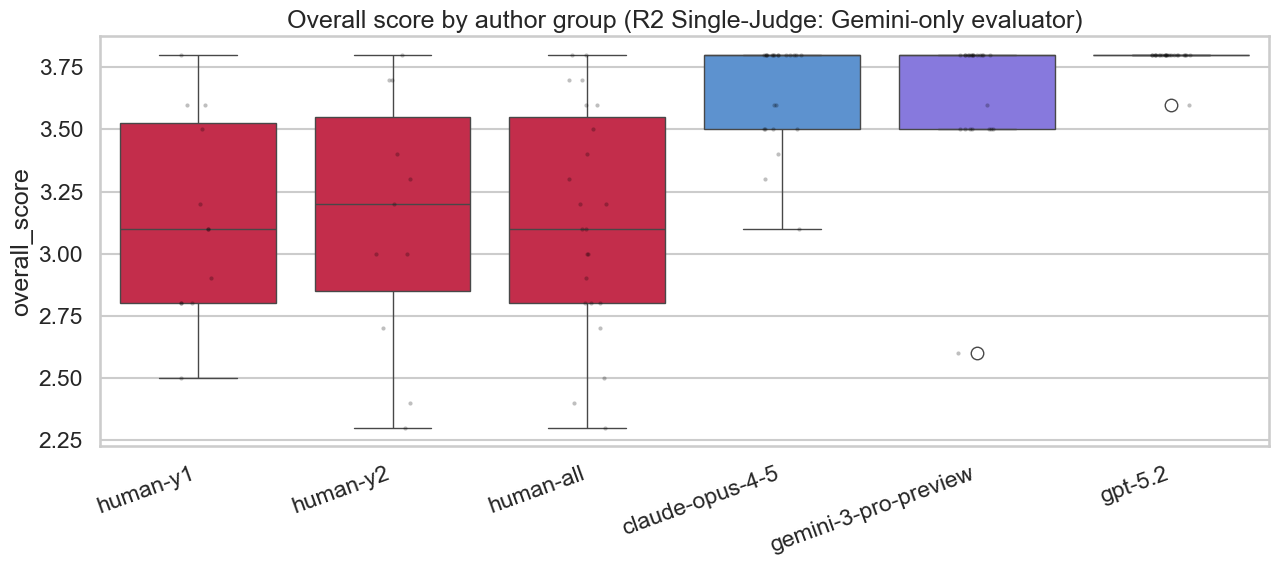

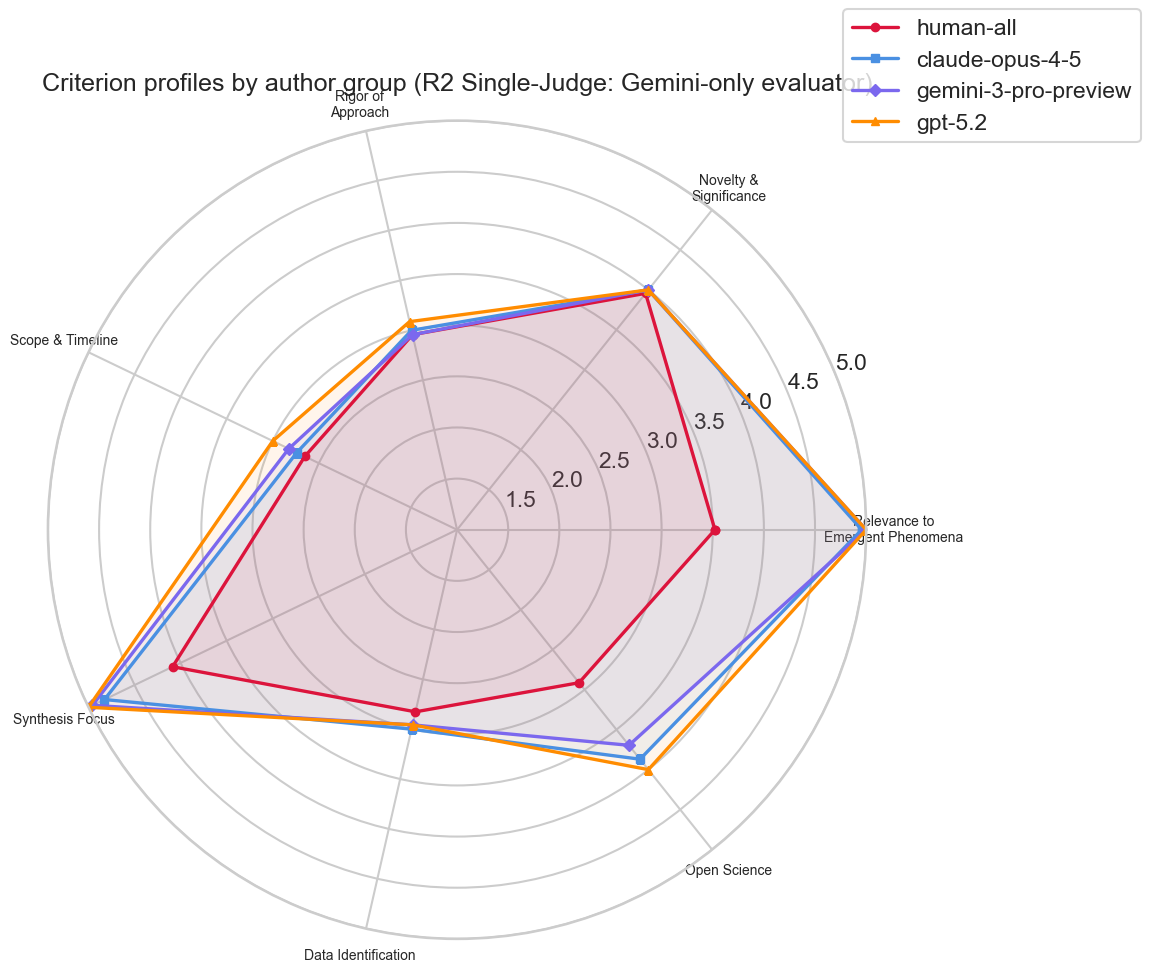

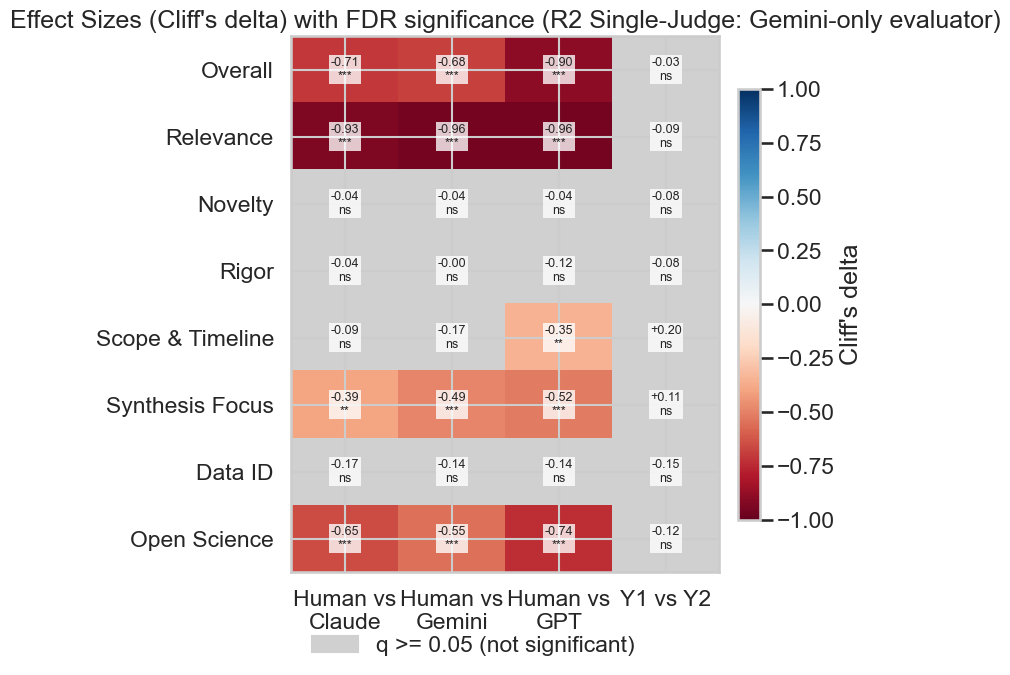

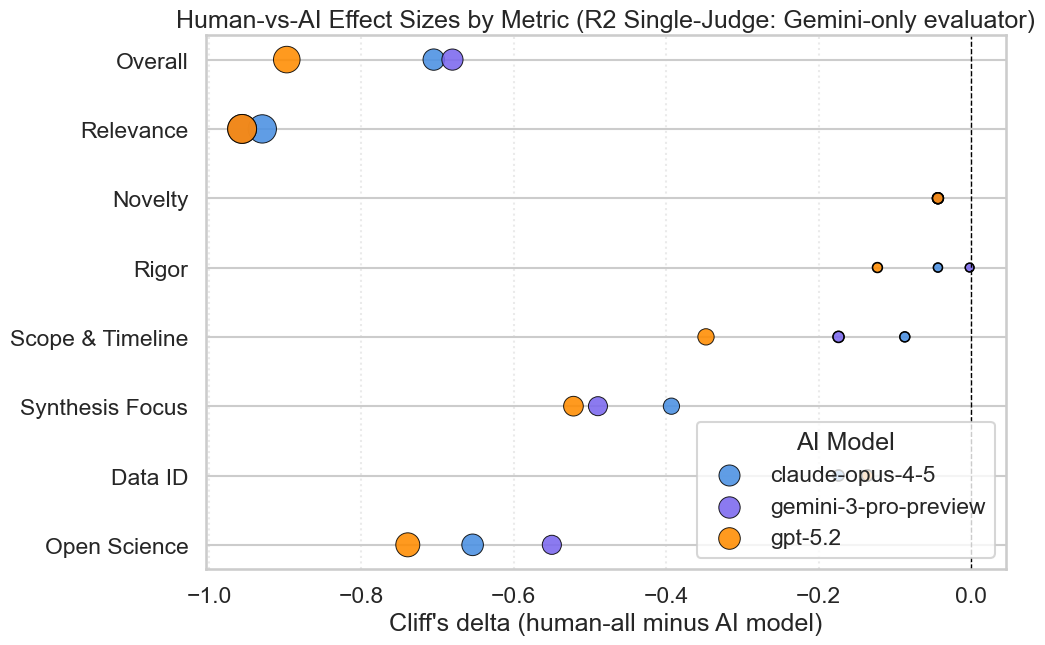

[R2 Single-Judge: Gemini-only evaluator] proposal-level N by group:


,group,n_proposals,overall_mean,overall_median,overall_std
0,human-y1,12,3.141667,3.1,0.405549
1,human-y2,11,3.136364,3.2,0.514340
2,human-all,23,3.139130,3.1,0.449989
3,claude-opus-4-5,23,3.660870,3.8,0.201673
4,gemini-3-pro-preview,23,3.647826,3.8,0.267768
5,gpt-5.2,23,3.791304,3.8,0.041703


[R2 Single-Judge: Gemini-only evaluator] human-all vs AI tests (FDR-adjusted):


,metric,n_group1,n_group2,u_stat,p_value,cliffs_delta,delta_magnitude,group1,group2,mean_group1,mean_group2,q_value
18,Data_Identification,23,23,218.5,1.645120e-01,-0.173913,small,human-all,claude-opus-4-5,2.826087,3.000000,2.948254e-01
19,Data_Identification,23,23,228.5,2.948254e-01,-0.136106,negligible,human-all,gemini-3-pro-preview,2.826087,2.956522,2.948254e-01
20,Data_Identification,23,23,228.5,2.948254e-01,-0.136106,negligible,human-all,gpt-5.2,2.826087,2.956522,2.948254e-01
6,Novelty_and_Significance,23,23,253.0,3.388087e-01,-0.043478,negligible,human-all,claude-opus-4-5,3.956522,4.000000,3.388087e-01
7,Novelty_and_Significance,23,23,253.0,3.388087e-01,-0.043478,negligible,human-all,gemini-3-pro-preview,3.956522,4.000000,3.388087e-01
8,Novelty_and_Significance,23,23,253.0,3.388087e-01,-0.043478,negligible,human-all,gpt-5.2,3.956522,4.000000,3.388087e-01
23,Open_Science_Commitment,23,23,69.0,6.036393e-07,-0.739130,large,human-all,gpt-5.2,2.913043,4.000000,1.810918e-06
21,Open_Science_Commitment,23,23,91.5,2.180938e-05,-0.654064,large,human-all,claude-opus-4-5,2.913043,3.869565,3.271408e-05
22,Open_Science_Commitment,23,23,119.0,4.732372e-04,-0.550095,large,human-all,gemini-3-pro-preview,2.913043,3.695652,4.732372e-04
4,Relevance_to_Emergent_Phenomena,23,23,11.5,1.226157e-09,-0.956522,large,human-all,gemini-3-pro-preview,3.521739,5.000000,1.839235e-09


[R2 Single-Judge: Gemini-only evaluator] robust sensitivity (head):


,metric,comparison,n_human_all,n_other,mean_diff,bootstrap_ci_lo,bootstrap_ci_hi,permutation_p_value,permutation_q_value
0,overall_score,human-all minus claude-opus-4-5,23,23,-0.521739,-0.708696,-0.317391,0.000200,0.000200
1,overall_score,human-all minus gemini-3-pro-preview,23,23,-0.508696,-0.708696,-0.291196,0.000200,0.000200
2,overall_score,human-all minus gpt-5.2,23,23,-0.652174,-0.821739,-0.465217,0.000200,0.000200
3,Relevance_to_Emergent_Phenomena,human-all minus claude-opus-4-5,23,23,-1.434783,-1.782609,-1.086957,0.000200,0.000200
4,Relevance_to_Emergent_Phenomena,human-all minus gemini-3-pro-preview,23,23,-1.478261,-1.782609,-1.173913,0.000200,0.000200
5,Relevance_to_Emergent_Phenomena,human-all minus gpt-5.2,23,23,-1.478261,-1.782609,-1.173913,0.000200,0.000200
6,Novelty_and_Significance,human-all minus claude-opus-4-5,23,23,-0.043478,-0.130435,0.000000,1.000000,1.000000
7,Novelty_and_Significance,human-all minus gemini-3-pro-preview,23,23,-0.043478,-0.130435,0.000000,1.000000,1.000000
8,Novelty_and_Significance,human-all minus gpt-5.2,23,23,-0.043478,-0.130435,0.000000,1.000000,1.000000
9,Rigor_of_Approach,human-all minus claude-opus-4-5,23,23,-0.043478,-0.173913,0.086957,1.000000,1.000000


In [30]:
# Restrict to Gemini evaluator only across all proposal authors.
ai_df_gemini_only = ai_df[ai_df['evaluator'] == 'gpt-5.2'].copy()

print('Rows retained (Gemini-only):', len(ai_df_gemini_only))
print('Proposal counts by author in Gemini-only set:')
display(ai_df_gemini_only.groupby('author')['proposal_id'].nunique().sort_index())

r2_gemini_only_results = run_r2_10_12_pipeline(
    reviews_df=ai_df_gemini_only,
    run_tag='gemini_only',
    run_label='R2 Single-Judge: Gemini-only evaluator',
)


### Interpretation: R2 Gemini-Only Re-Run

- This isolates conclusions under a single judge model to remove inter-evaluator variance.
- If Gemini-only results differ strongly from multi-evaluator R2, evaluator identity is a major driver.
- Use this as a sensitivity analysis, not a replacement for multi-judge inference.
